MvTec Anamoly Detection Project - Exploration des données + DataViz

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from PIL import Image
from pathlib import Path
from collections import Counter

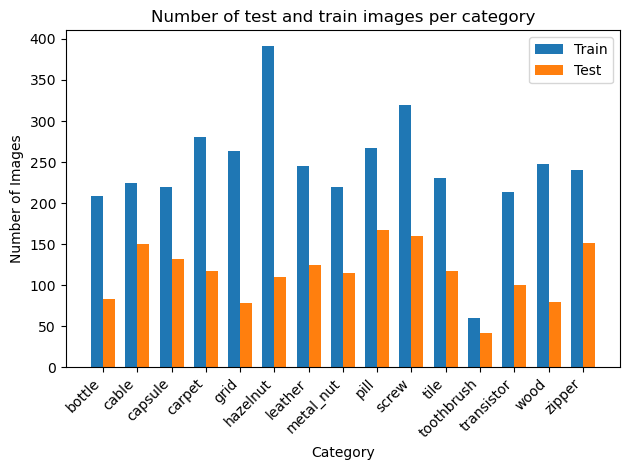

In [2]:
train_files = []
test_files = []
test_subFolders = []
categories = [p.name for p in Path(f"../Projects/mvtec_anomaly_detection/").iterdir() if p.is_dir()]
#category="capsule"

for category in categories:
    train_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/train")
    test_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/test")

    train_files_count = sum(1 for f in train_dir.rglob('*') if f.is_file())
    test_files_count = sum(1 for f in test_dir.rglob('*') if f.is_file())   
    train_files.append(train_files_count)
    test_files.append(test_files_count)    
    
    test_subFolders_count = sum(1 for f in test_dir.iterdir() if f.is_dir() and f.name != 'good' )
    test_subFolders.append(test_subFolders_count)

#print(test_subFolders)
#print(np.sum(test_array))
#print(test_array)
#print(train_total)

x = np.arange(len(categories))
width = 0.35
plt.bar(x - width/2 , train_files, width, label="Train")
plt.bar(x + width/2 , test_files, width, label="Test")
plt.title("Number of test and train images per category")
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.xticks(x, categories, rotation=45, ha="right" )
plt.legend()
plt.tight_layout()
plt.show()

In the above figure, we can note that hazelnut has more training data and toothbrush has less training and test data.
Categories like grid and hazelnut have less test images compared to their train images

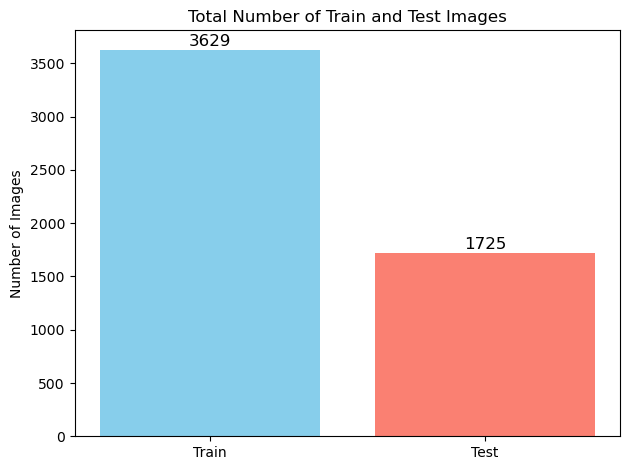

In [3]:
train_files_total=np.sum(train_files)
test_files_total=np.sum(test_files)
#print(train_total, test_total)

bars = plt.bar(['Train','Test'],[train_files_total, test_files_total],  color=['skyblue', 'salmon'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom', fontsize=12)
    
plt.ylabel('Number of Images')
plt.title('Total Number of Train and Test Images')
plt.tight_layout()
plt.show()

From the above graph, we have approximately 50% of training data as test data.
The taotal number of images in our dataset is 5354.

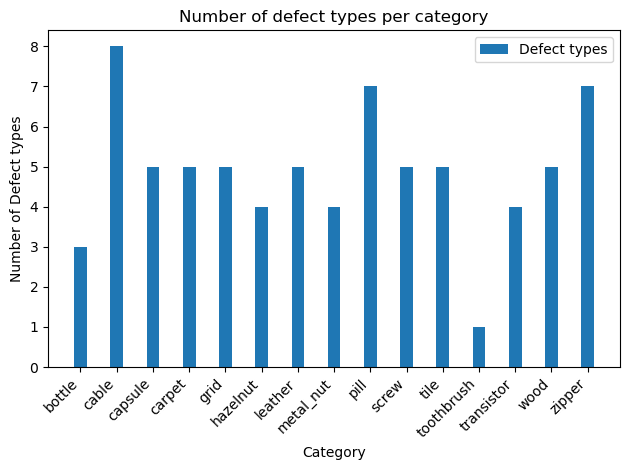

In [4]:
x = np.arange(len(categories))
width = 0.35
plt.bar(x , test_subFolders, width, label="Defect types")

plt.title("Number of defect types per category")
plt.xlabel("Category")
plt.ylabel("Number of Defect types")
plt.xticks(x, categories, rotation=45, ha="right" )
plt.legend()
plt.tight_layout()
plt.show()

From the above graph, we can see that the category having highest number of defect types is cable. 
It has 8 defect types, followed by pill and zipper having 7 defect types. 
The category having less defect types is toothbrust. It has only 1 defect type.

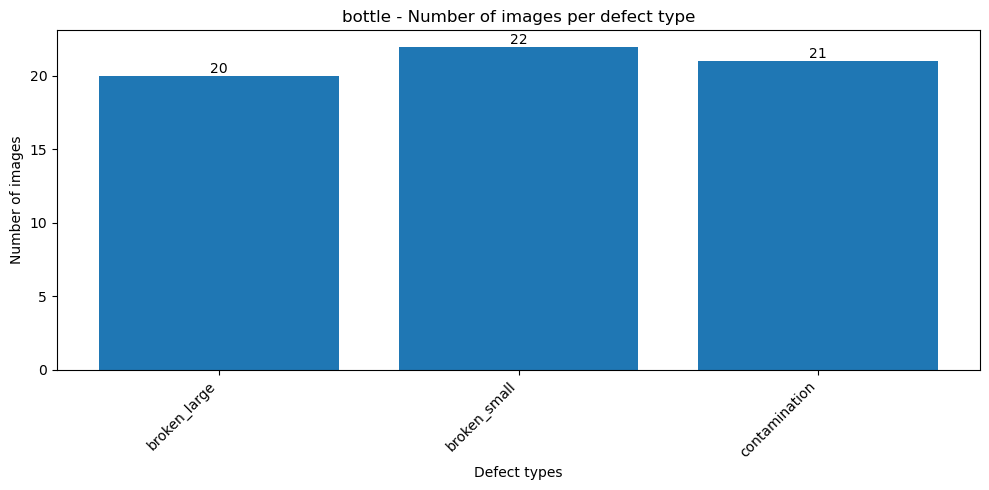

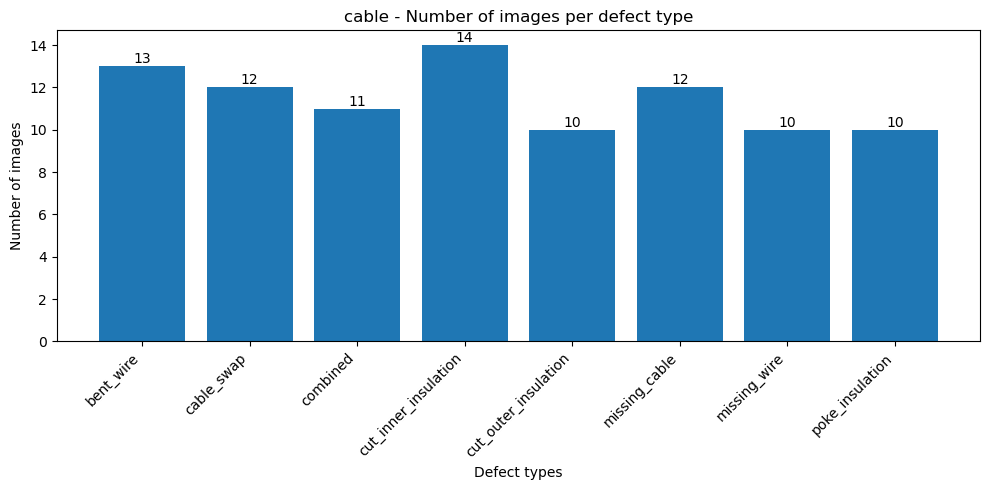

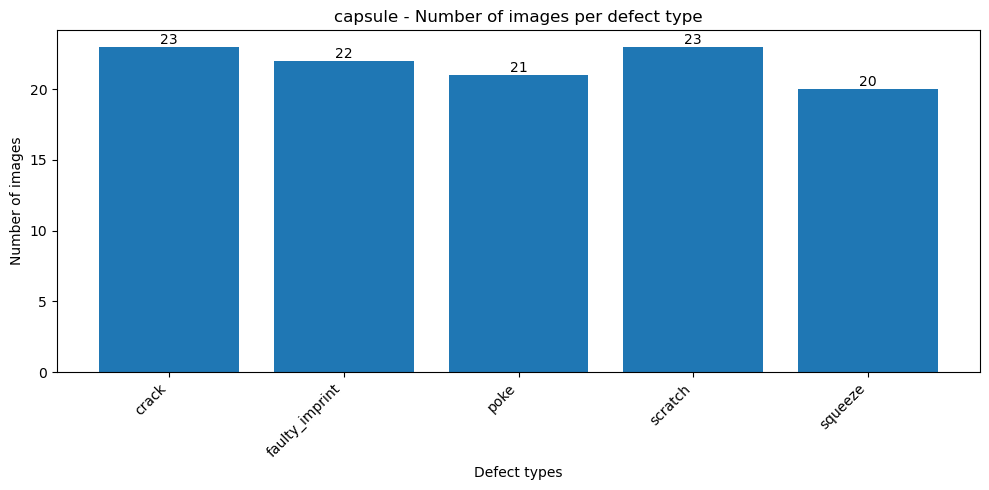

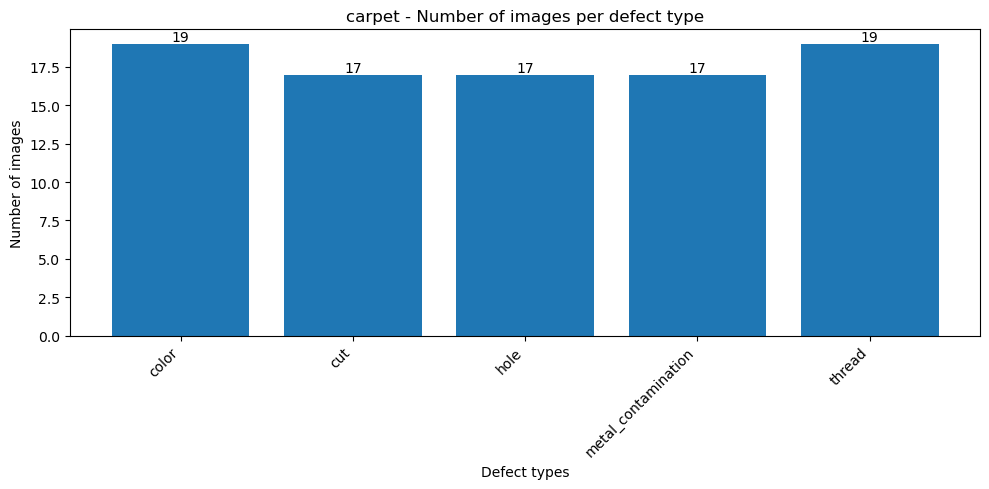

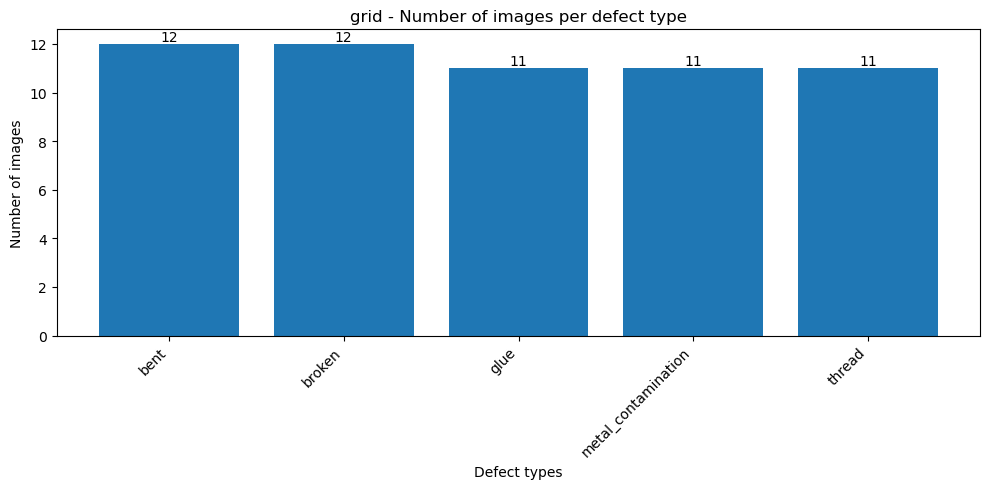

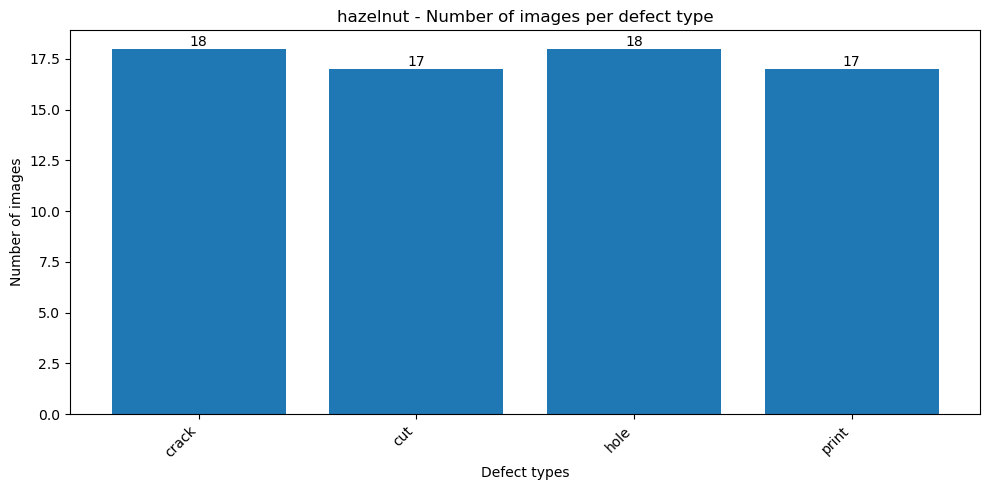

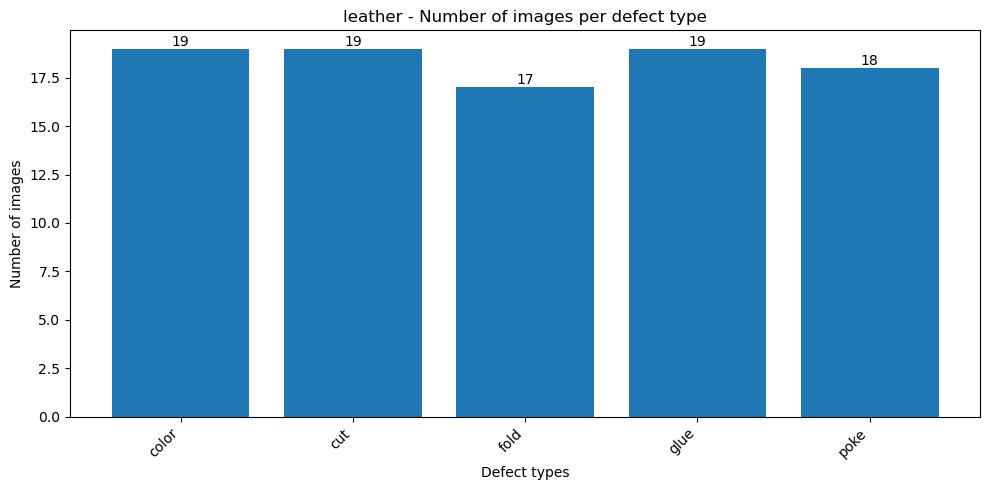

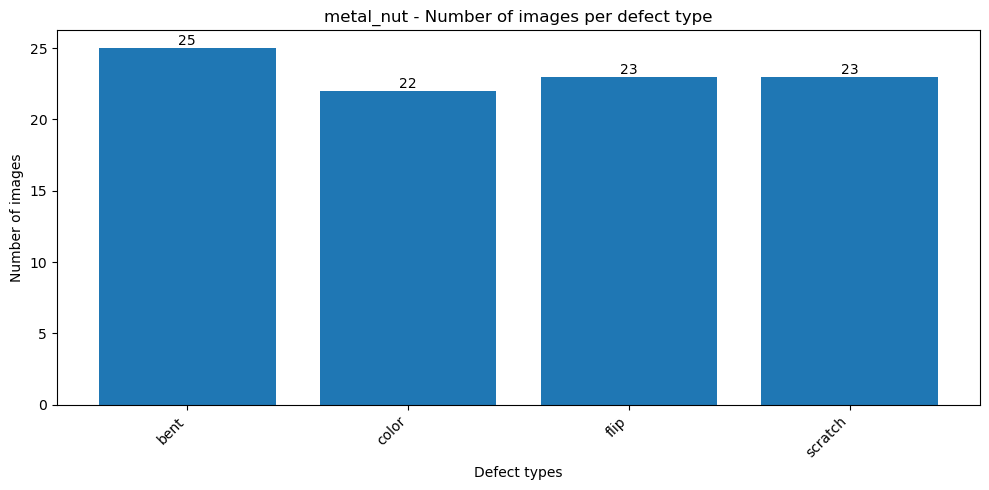

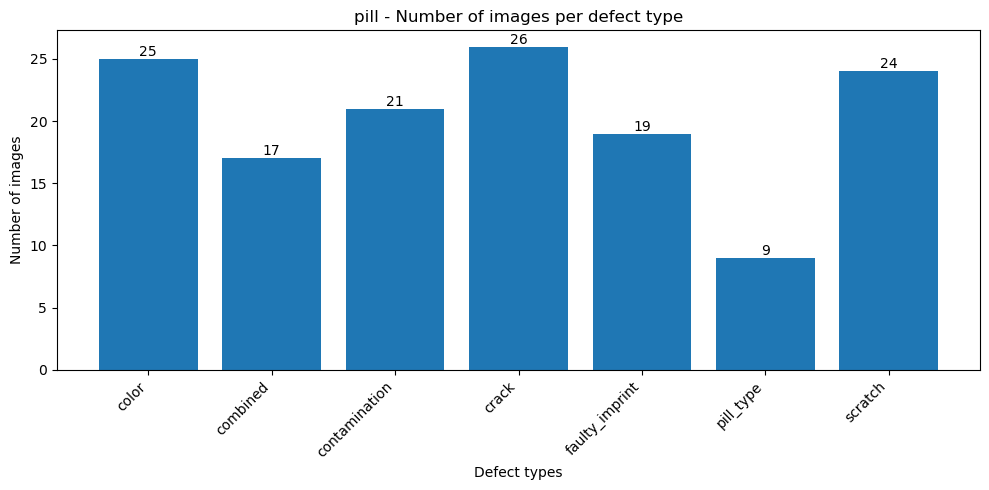

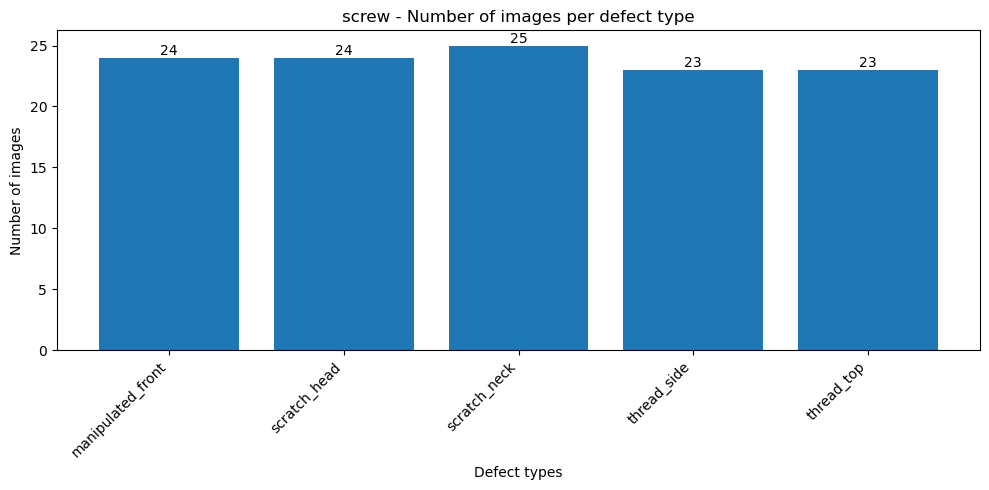

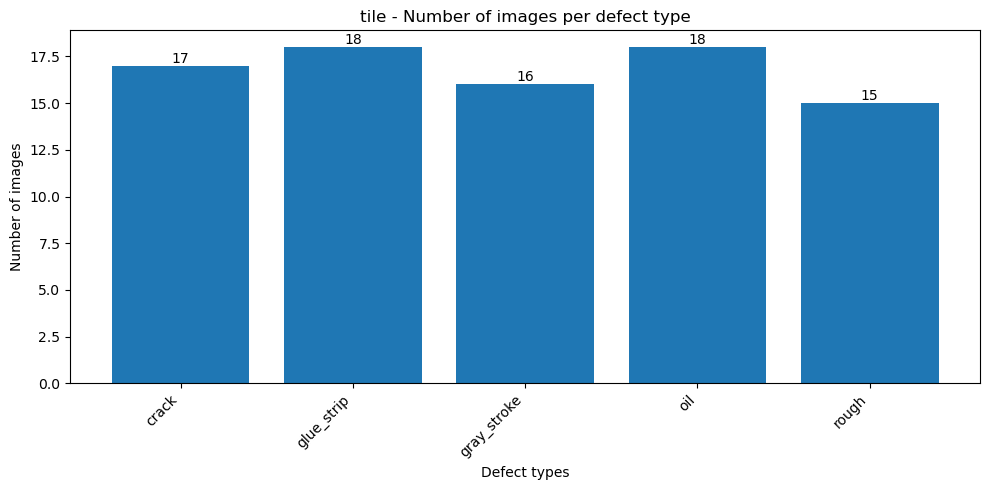

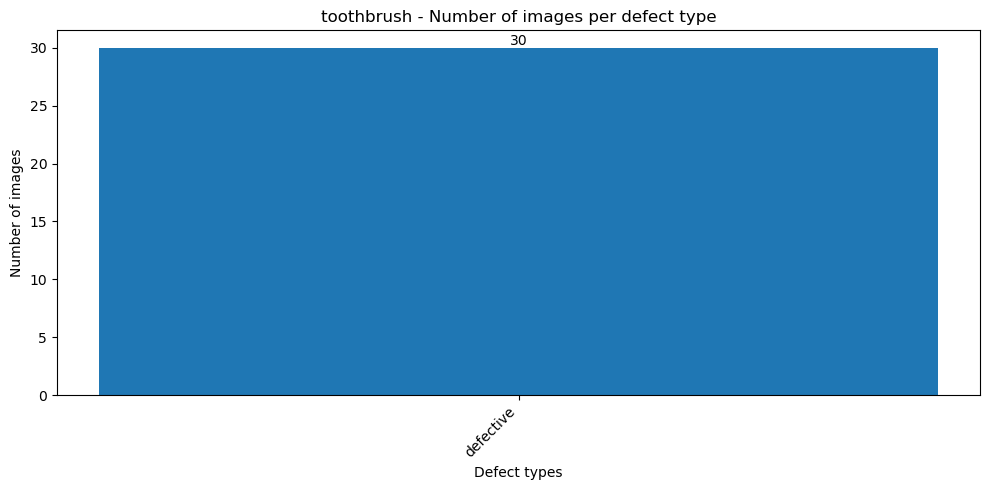

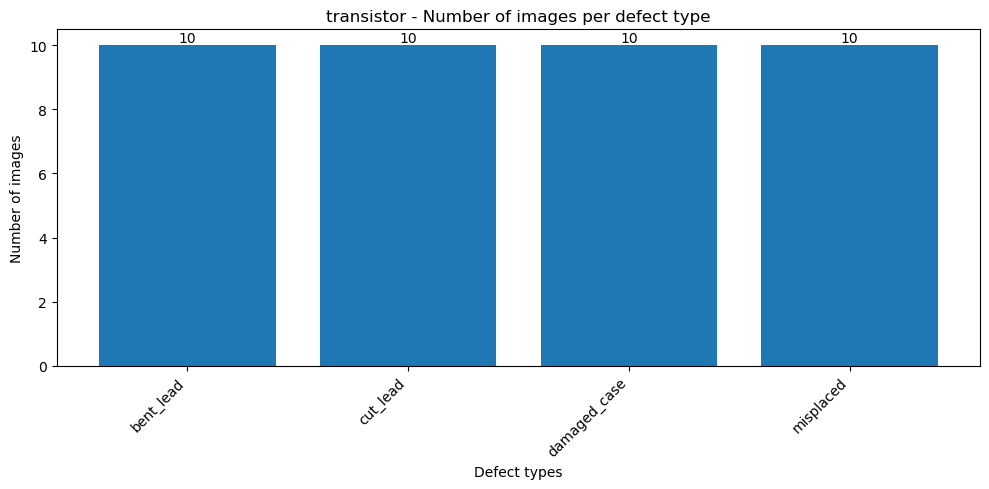

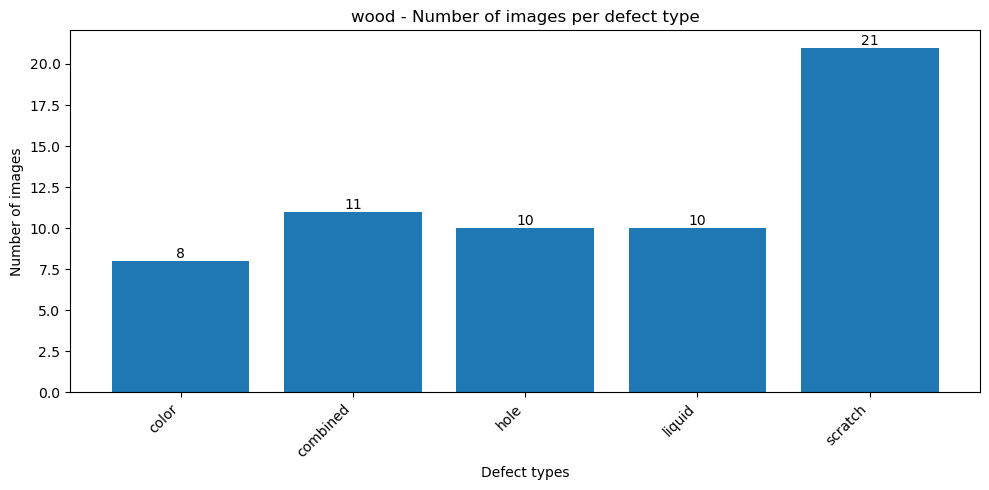

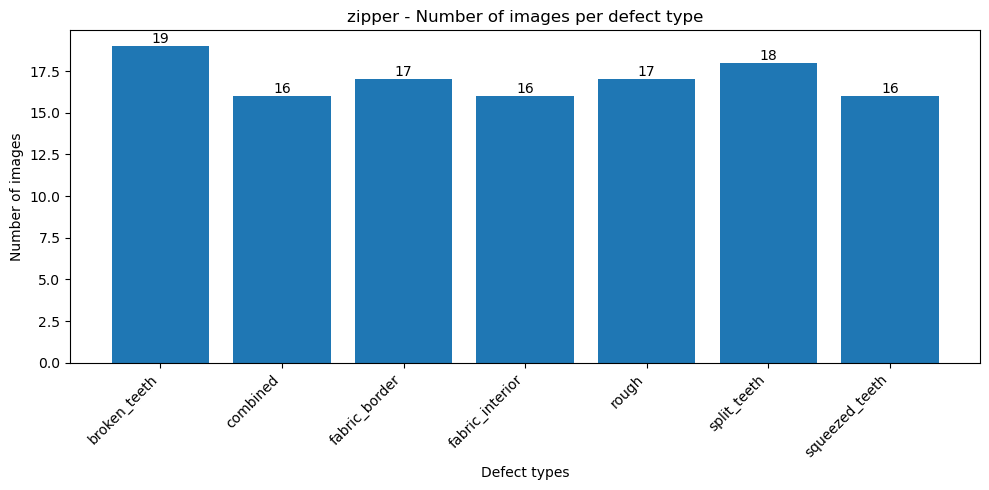

In [5]:
for category in categories:
    test_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/test")
    
    # Collect subfolder names and file counts
    subfolder_names = []
    file_counts = []
    
    for subfolder in test_dir.iterdir():
        if subfolder.is_dir() and subfolder.name!='good':
            subfolder_names.append(subfolder.name)
            num_files = sum(1 for f in subfolder.iterdir() if f.is_file())
            file_counts.append(num_files)
    
    # Plot
    plt.figure(figsize=(10,5))
    bars = plt.bar(subfolder_names, file_counts)
    
    # Add counts on top of each bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, yval, ha='center', va='bottom')
    
    plt.xlabel('Defect types')
    plt.ylabel('Number of images')
    plt.title(category + ' - Number of images per defect type')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

From the above graph, we can see that we have 10 to 30 defective images in each category defect type.
Most of them have approximately 20 images in each defect type

[np.float64(5.632696151733398), np.float64(3.6979007720947266), np.float64(9.018101692199707), np.float64(3.132491111755371), np.float64(7.9869890213012695), np.float64(9.177389144897461), np.float64(9.918136596679688), np.float64(9.375343322753906), np.float64(4.7808122634887695), np.float64(9.290227890014648), np.float64(9.265909194946289), np.float64(28.995423316955566), np.float64(17.598466873168945)]


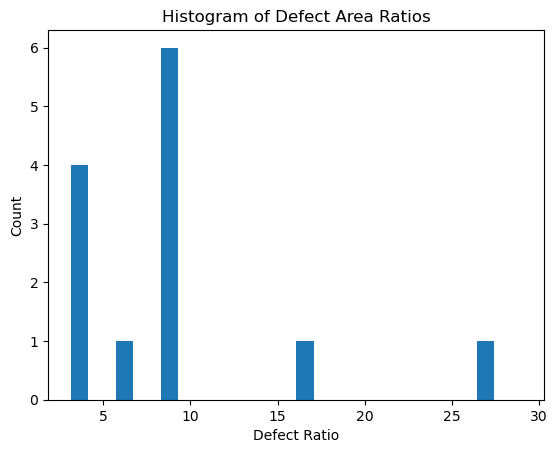

In [6]:
category = "cable"
mask_dir = f"../Projects/mvtec_anomaly_detection/{category}/ground_truth/bent_wire/"
test_dir = f"../Projects/mvtec_anomaly_detection/{category}/test/bent_wire/"
mask_area_ratios = []
for mask_file in os.listdir(mask_dir):
    mask = cv2.imread(os.path.join(mask_dir, mask_file), cv2.IMREAD_GRAYSCALE)
    mask_area_ratios.append(mask.sum() / (mask.shape[0]*mask.shape[1]))
print(mask_area_ratios)
plt.hist(mask_area_ratios, width=1)
plt.title("Histogram of Defect Area Ratios")
plt.xlabel("Defect Ratio")
plt.ylabel("Count")
plt.show()

From the above analysis of the cable category bent wire defect, 2 images are having large defects ( Defect ratio - 17 and 27)
The remaining 11 images are having small defects ( Defect ratio is less than 10)

In [61]:
# DataFrame which gets all images in MvTec dataset with their properties
image_files = list(Path(f"../Projects/mvtec_anomaly_detection/").rglob("*"))
image_files = [f for f in image_files if f.is_file() and f.suffix.lower() in ('.png','.jpg','jpeg','.gif')]

#print(len(image_files))
print(image_files[0])
img = Image.open(image_files[0])
print(img.size)
#print(os.path.dirname(image_files[100]))
#print(os.path.basename(os.path.dirname(image_files[100])))

df = pd.DataFrame({
    "file_path": image_files,
    "category_name": [f.parent.parent.parent.name for f in image_files],
    "dir_name": [f.parent.name for f in image_files],
    "file_name": [f.name for f in image_files], 
    "file_size": [f.stat().st_size for f in image_files],
    "label":  [0 if f.parent.name == "good" else 1 for f in image_files], 
    "img": [Image.open(f) for f in image_files]
})

#df["img_size"] = df["img"].size
#(df.iloc[1000,6]).size[0]
df

..\Projects\mvtec_anomaly_detection\bottle\ground_truth\broken_large\000_mask.png
(900, 900)


,file_path,category_name,dir_name,file_name,file_size,label,img,img_size
0,..\Projects\mvtec_anomaly_detection\bottle\gro...,bottle,broken_large,000_mask.png,4109,1,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612
1,..\Projects\mvtec_anomaly_detection\bottle\gro...,bottle,broken_large,001_mask.png,4057,1,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612
2,..\Projects\mvtec_anomaly_detection\bottle\gro...,bottle,broken_large,002_mask.png,4405,1,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612
3,..\Projects\mvtec_anomaly_detection\bottle\gro...,bottle,broken_large,003_mask.png,5787,1,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612
4,..\Projects\mvtec_anomaly_detection\bottle\gro...,bottle,broken_large,004_mask.png,3380,1,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612
...,...,...,...,...,...,...,...,...
6607,..\Projects\mvtec_anomaly_detection\zipper\tra...,zipper,good,235.png,423869,0,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612
6608,..\Projects\mvtec_anomaly_detection\zipper\tra...,zipper,good,236.png,425414,0,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612
6609,..\Projects\mvtec_anomaly_detection\zipper\tra...,zipper,good,237.png,420235,0,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612
6610,..\Projects\mvtec_anomaly_detection\zipper\tra...,zipper,good,238.png,402324,0,<PIL.PngImagePlugin.PngImageFile image mode=L ...,6612


bottle
Train images -  Counter({'PNG': 209}) Counter({'RGB': 209})
Test images -  Counter({'PNG': 83}) Counter({'RGB': 83})
cable
Train images -  Counter({'PNG': 224}) Counter({'RGB': 224})
Test images -  Counter({'PNG': 150}) Counter({'RGB': 150})
capsule
Train images -  Counter({'PNG': 219}) Counter({'RGB': 219})
Test images -  Counter({'PNG': 132}) Counter({'RGB': 132})
carpet
Train images -  Counter({'PNG': 280}) Counter({'RGB': 280})
Test images -  Counter({'PNG': 117}) Counter({'RGB': 117})
grid
Train images -  Counter({'PNG': 264}) Counter({'L': 264})
Test images -  Counter({'PNG': 78}) Counter({'L': 78})
hazelnut
Train images -  Counter({'PNG': 391}) Counter({'RGB': 391})
Test images -  Counter({'PNG': 110}) Counter({'RGB': 110})
leather
Train images -  Counter({'PNG': 245}) Counter({'RGB': 245})
Test images -  Counter({'PNG': 124}) Counter({'RGB': 124})
metal_nut
Train images -  Counter({'PNG': 220}) Counter({'RGB': 220})
Test images -  Counter({'PNG': 115}) Counter({'RGB': 11

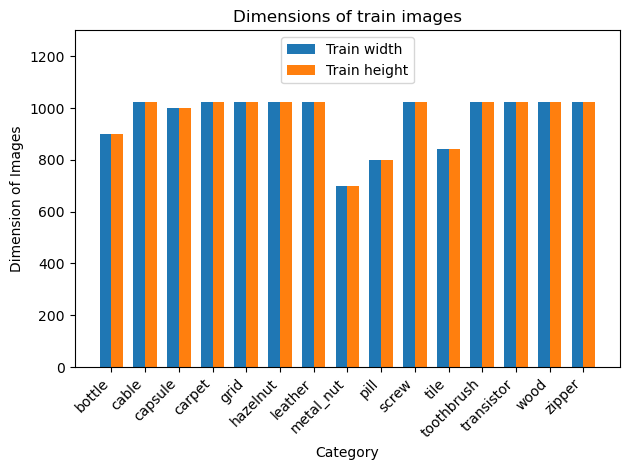

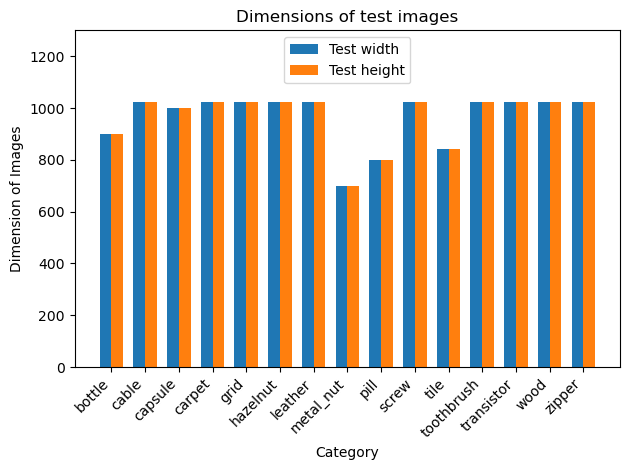

In [50]:
# This code displays the graph comparing height and width of all train and test images
# This code also gives image formats and modes of all train and test images

categories = [p.name for p in Path(f"../Projects/mvtec_anomaly_detection/").iterdir() if p.is_dir()]
#categories = ["bottle"]

train_width = []
train_height = []
test_width = []
test_height = []

for category in categories:
    dimensions = []    
    formats = []
    modes = []
    dimensions_test = []
    formats_test = []
    modes_test = []
    train_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/train")
    test_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/test")

    train_files = [f for f in train_dir.rglob('*') if f.is_file()]
    test_files = [f for f in test_dir.rglob('*') if f.is_file()]

    for img in train_files:
        with Image.open(img) as img:
            dimensions.append(img.size)
            formats.append(img.format)
            modes.append(img.mode)

    widths, heights = zip(*dimensions)   
    avg_width = np.mean(widths)
    avg_height = np.mean(heights)
    
    print(category)
    print("Train images - ", Counter(formats), Counter(modes))
    train_width.append(avg_width)
    train_height.append(avg_height)

    formats = []
    modes = []
    for img in test_files:
        with Image.open(img) as img:
            dimensions_test.append(img.size)
            formats.append(img.format)
            modes.append(img.mode)

    widths, heights = zip(*dimensions_test)
    avg_width_test = np.mean(widths)
    avg_height_test = np.mean(heights)
  
    print("Test images - ", Counter(formats), Counter(modes))
    test_width.append(avg_width_test)
    test_height.append(avg_height_test)

#print(categories)    
#print(test_width)  
#print(test_height)

# Display graphs
x = np.arange(len(categories))
width = 0.35
plt.bar(x - width/2 , train_width, width, label="Train width")
plt.bar(x + width/2 , train_height, width, label="Train height")
plt.title("Dimensions of train images")
plt.xlabel("Category")
plt.ylabel("Dimension of Images")
plt.xticks(x, categories, rotation=45, ha="right" )
plt.ylim(0, 1300)
plt.legend(loc="upper center")
plt.tight_layout()
plt.show()

plt.bar(x - width/2 , test_width, width, label="Test width")
plt.bar(x + width/2 , test_height, width, label="Test height")
plt.title("Dimensions of test images")
plt.xlabel("Category")
plt.ylabel("Dimension of Images")
plt.xticks(x, categories, rotation=45, ha="right" )
plt.ylim(0, 1300)
plt.legend(loc="upper center")
plt.tight_layout()
plt.show()


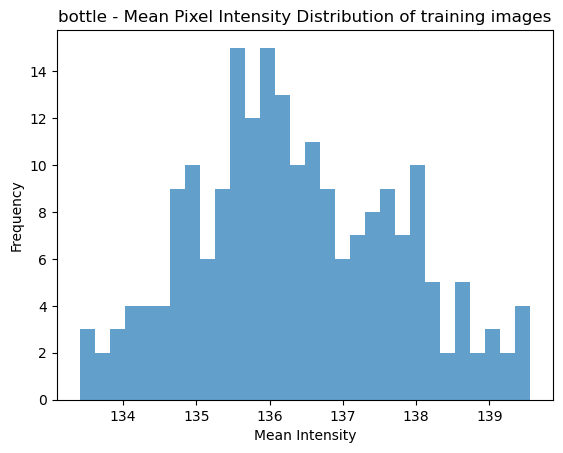

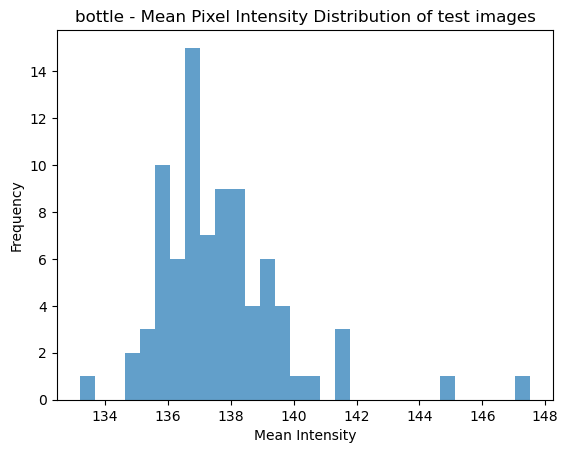

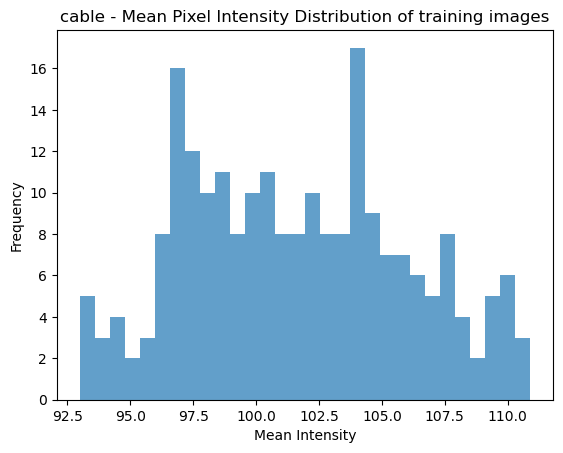

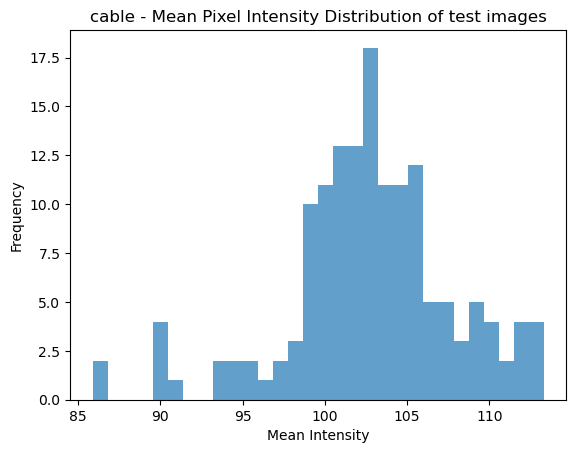

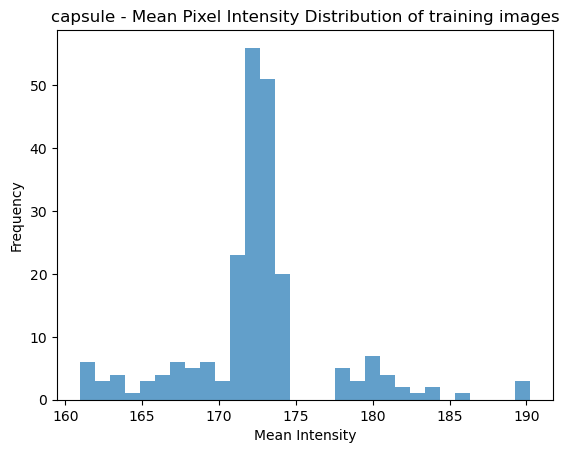

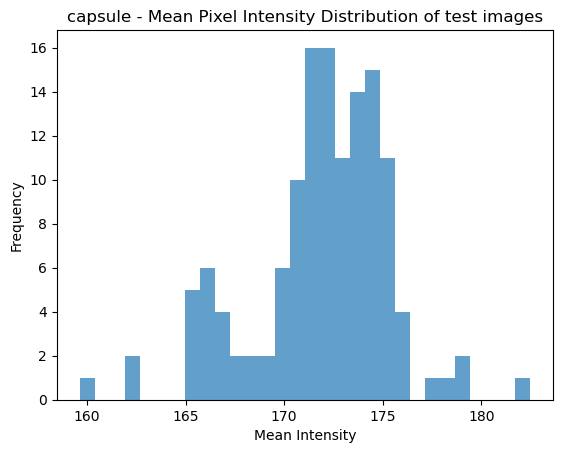

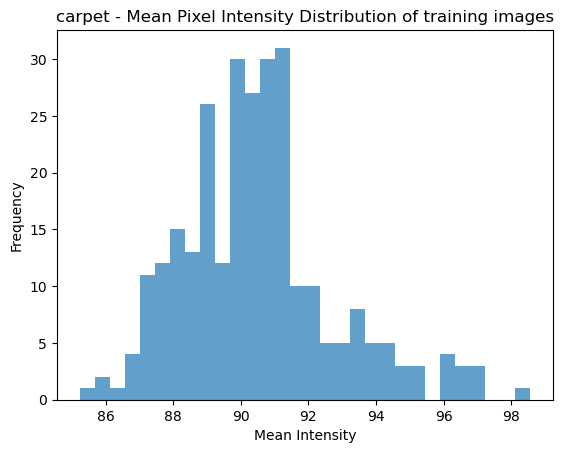

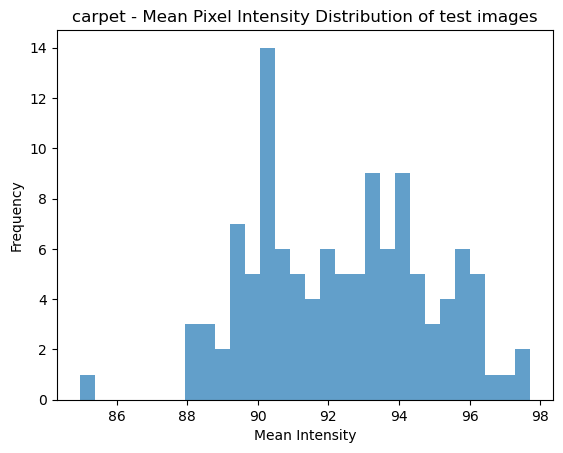

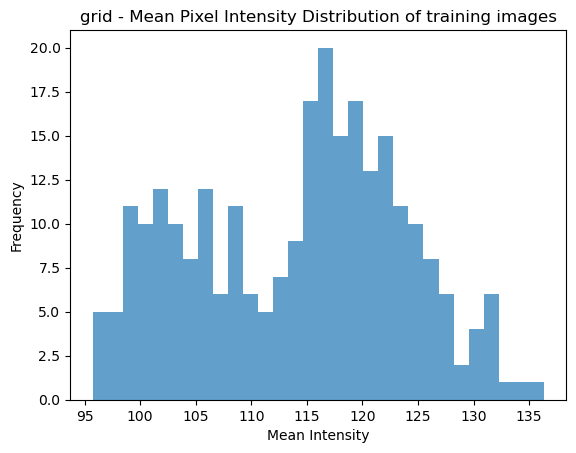

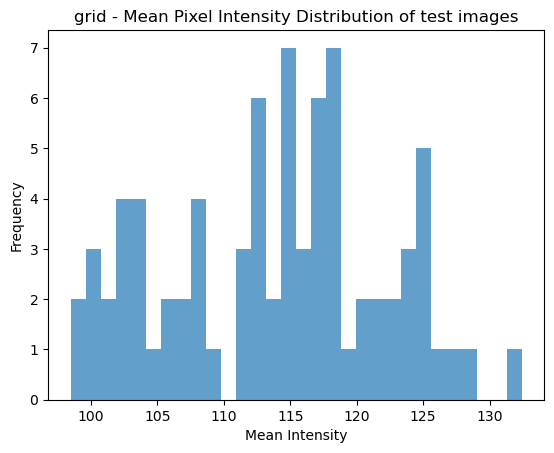

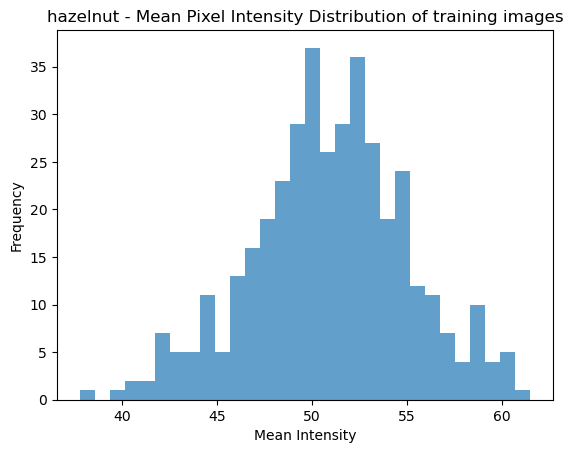

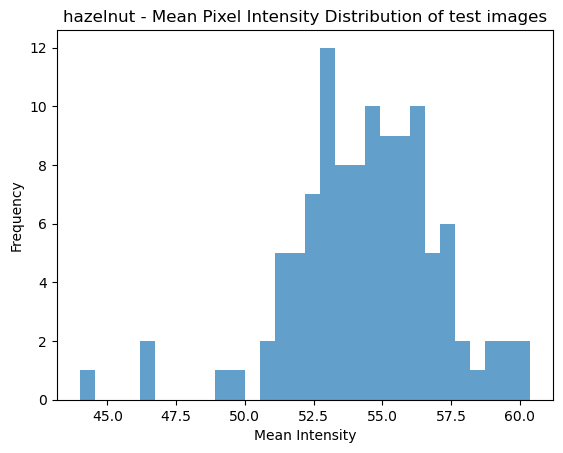

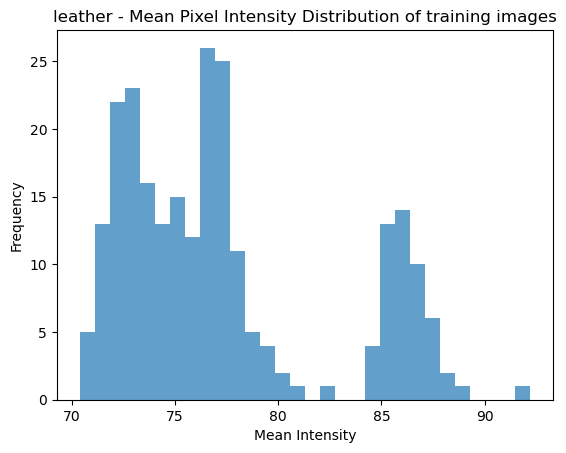

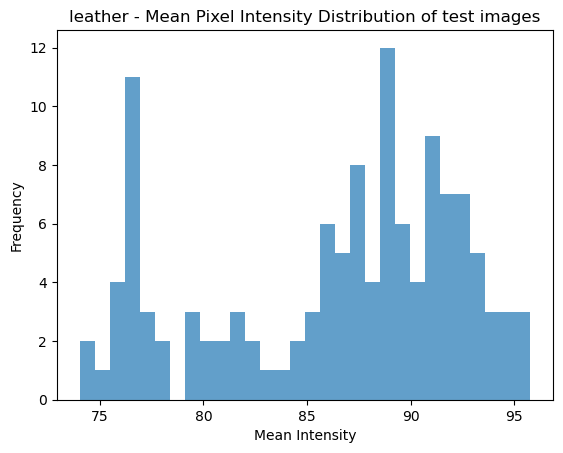

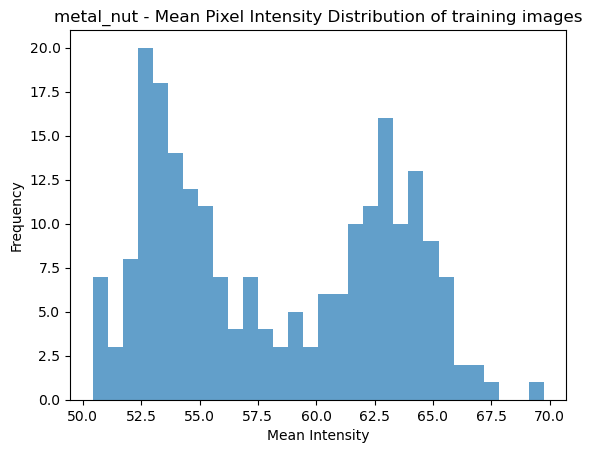

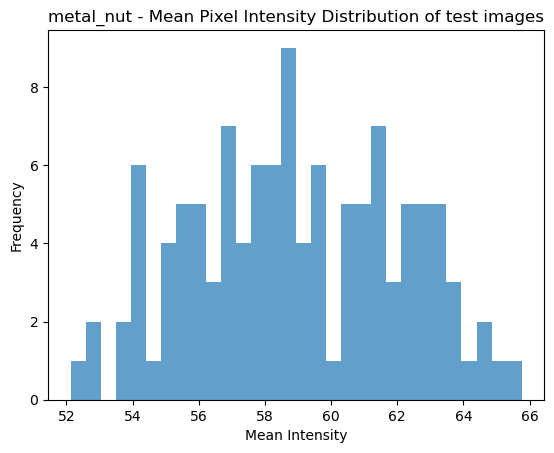

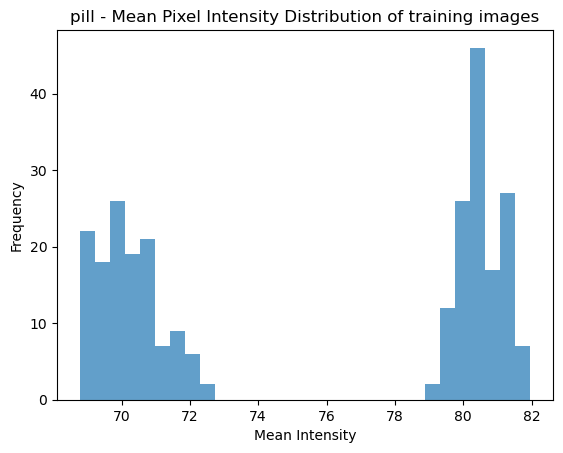

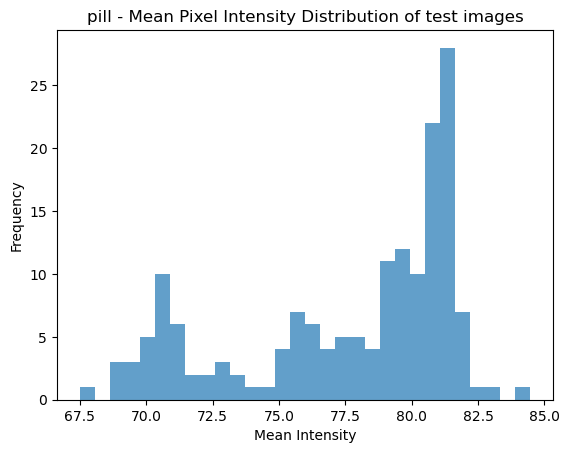

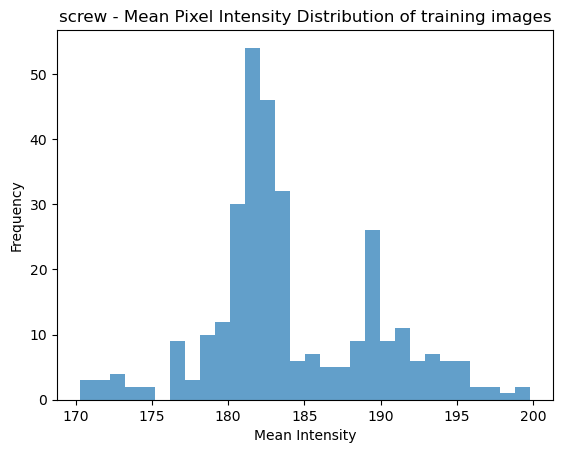

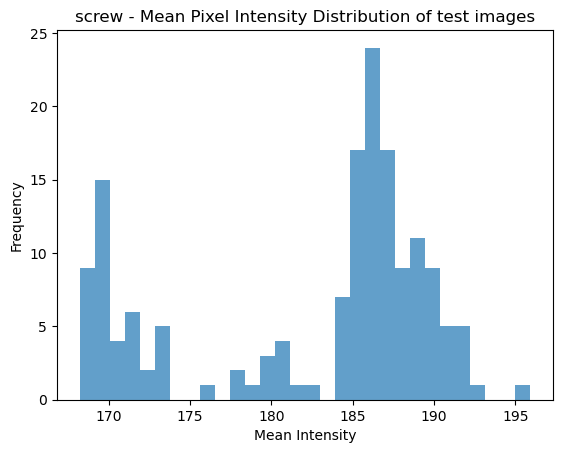

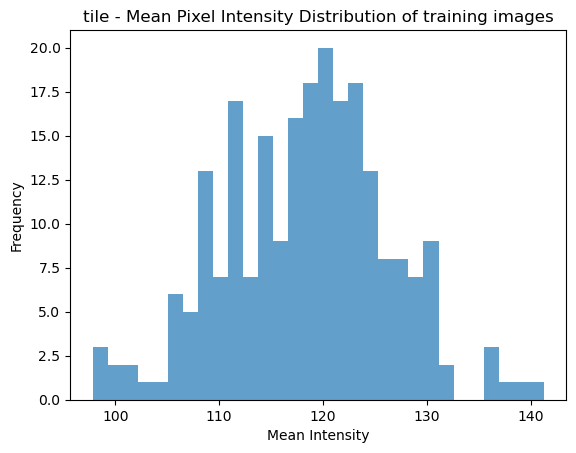

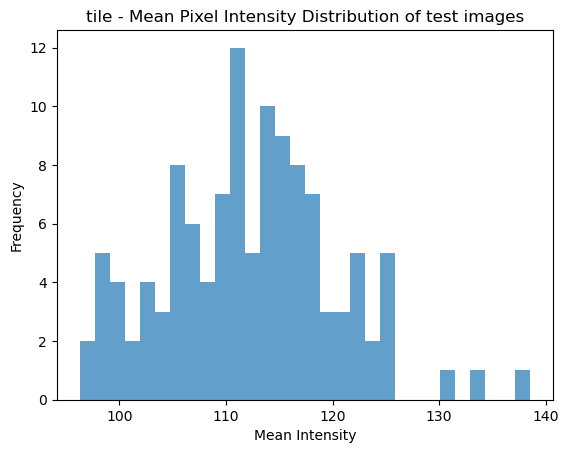

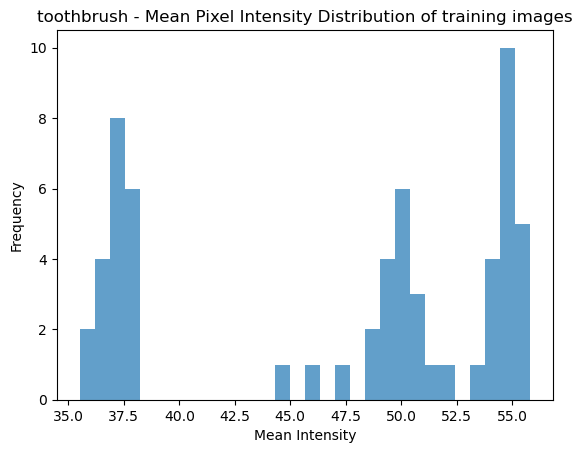

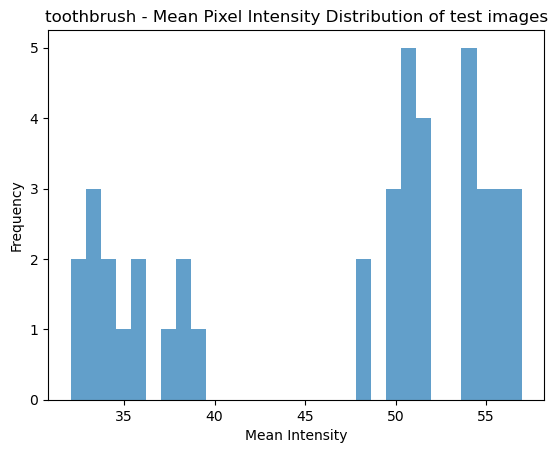

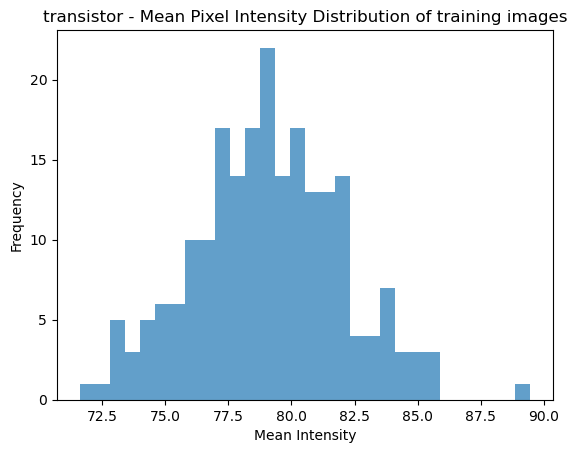

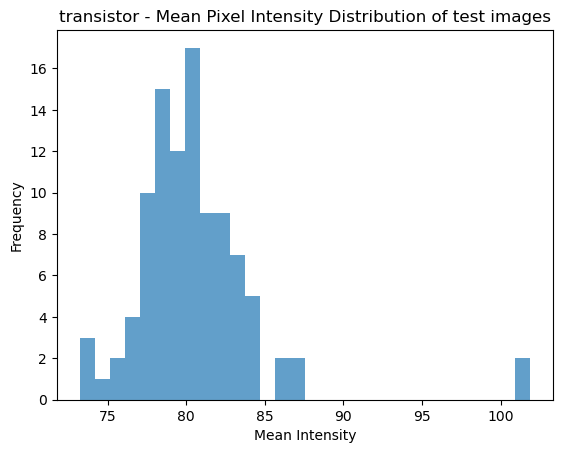

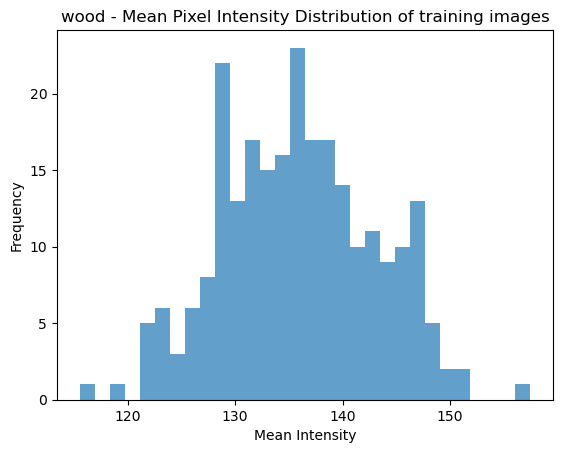

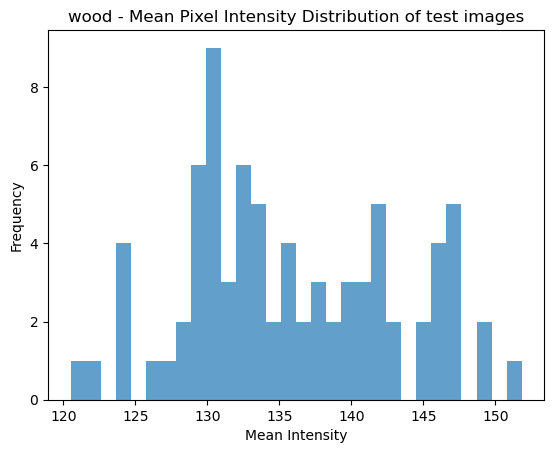

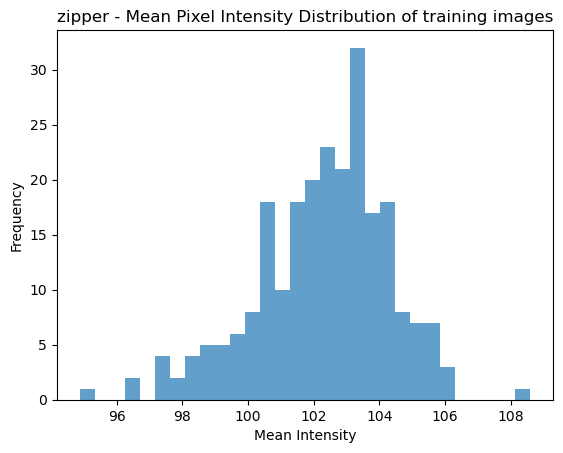

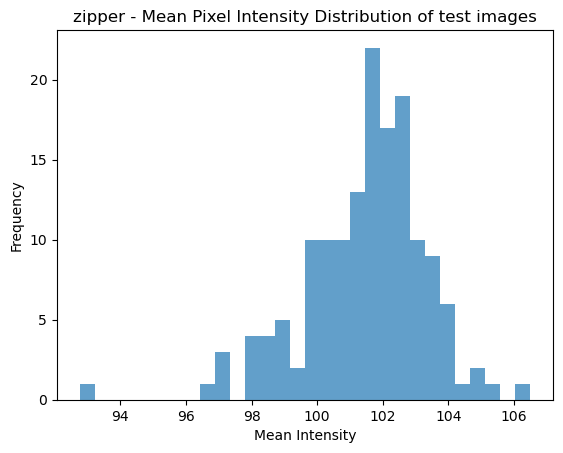

In [29]:
# Analysis graphs comparing brightness of test and train images of each category
categories = [p.name for p in Path(f"../Projects/mvtec_anomaly_detection/").iterdir() if p.is_dir()]
#categories = ["bottle","cable","capsule"]
gray_means_all = []

for category in categories:
    gray_means = []

    train_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/train")
    test_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/test")

    train_files = [f for f in train_dir.rglob('*') if f.is_file()]
    test_files = [f for f in test_dir.rglob('*') if f.is_file()]

    for img in train_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        gray_means.append(np.mean(img_array))
    gray_means_all.append(np.mean(gray_means))

    plt.hist(gray_means, bins=30, alpha=0.7)
    plt.title(category + " - Mean Pixel Intensity Distribution of training images")
    plt.xlabel("Mean Intensity")
    plt.ylabel("Frequency")
    plt.show()

    gray_means = []
    for img in test_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        gray_means.append(np.mean(img_array))

    plt.hist(gray_means, bins=30, alpha=0.7)
    plt.title(category + " - Mean Pixel Intensity Distribution of test images")
    plt.xlabel("Mean Intensity")
    plt.ylabel("Frequency")
    plt.show()
  


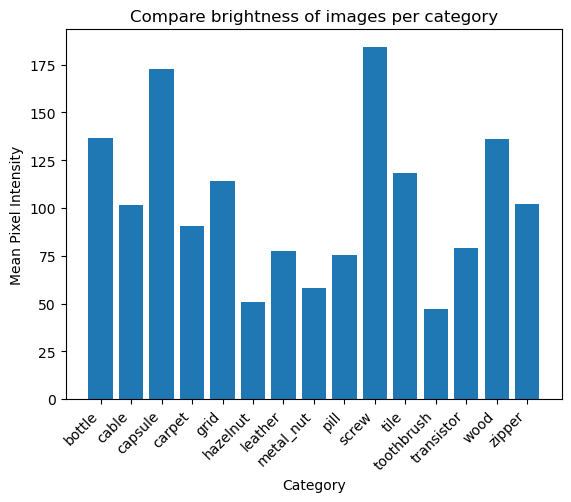

In [25]:
# Analysis graph to compare brightness of train images in all categories
plt.bar(categories, gray_means_all)
plt.xticks(categories, categories, rotation=45, ha="right" );
plt.title("Compare brightness of images per category")
plt.xlabel("Category")
plt.ylabel("Mean Pixel Intensity");

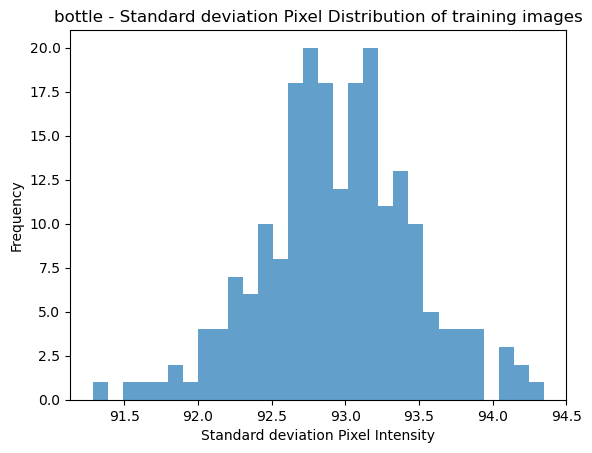

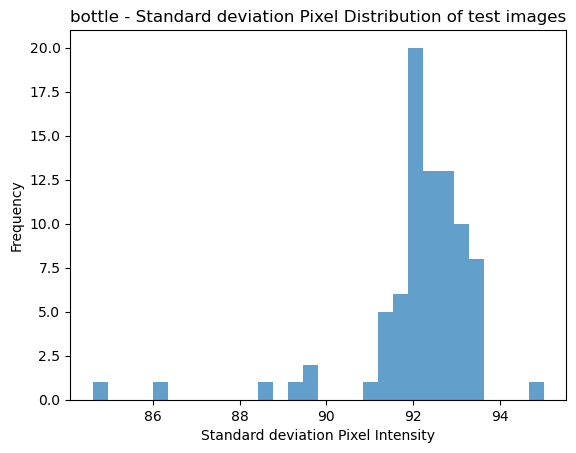

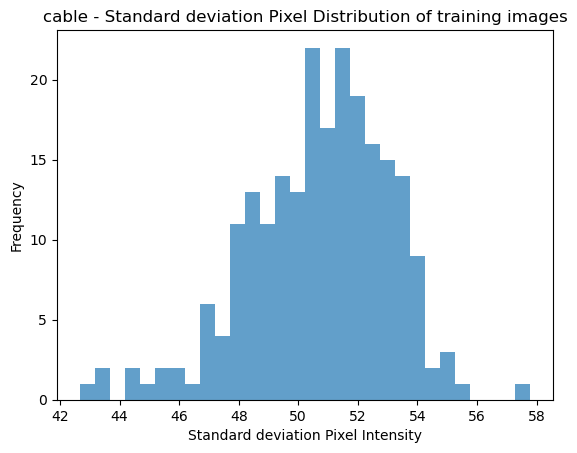

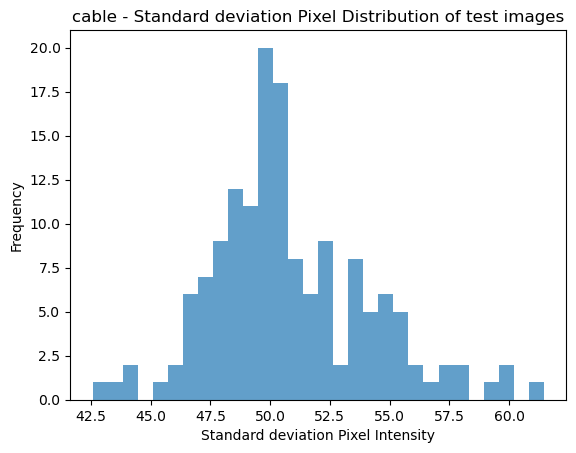

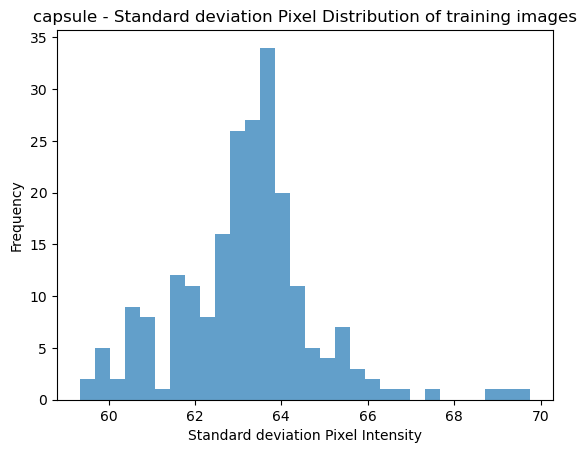

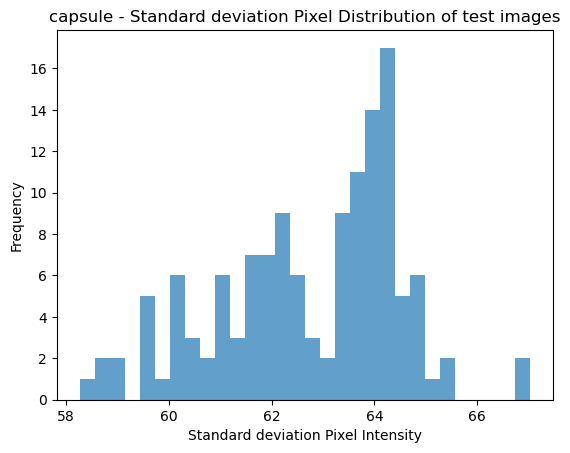

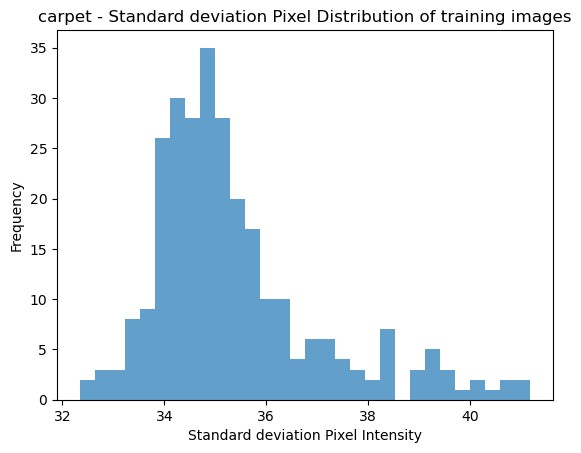

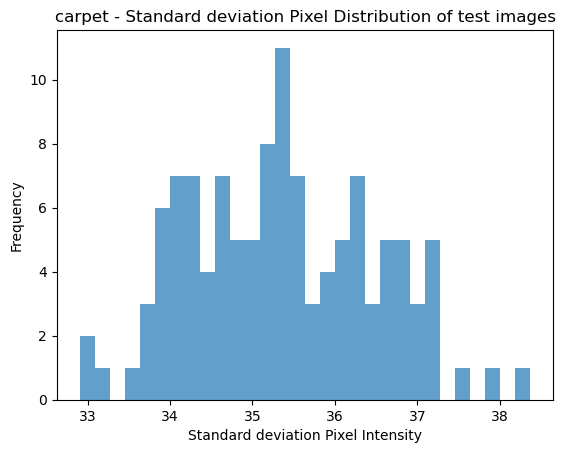

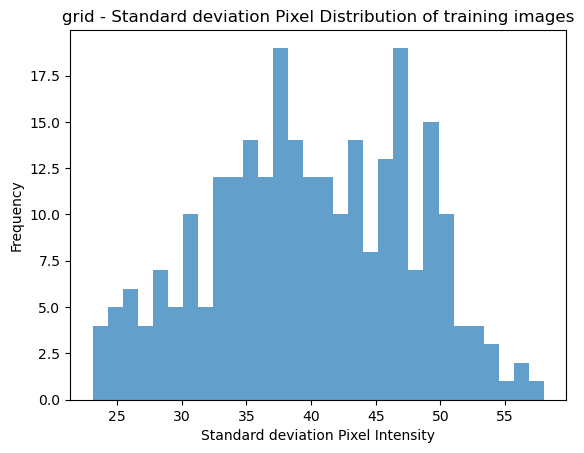

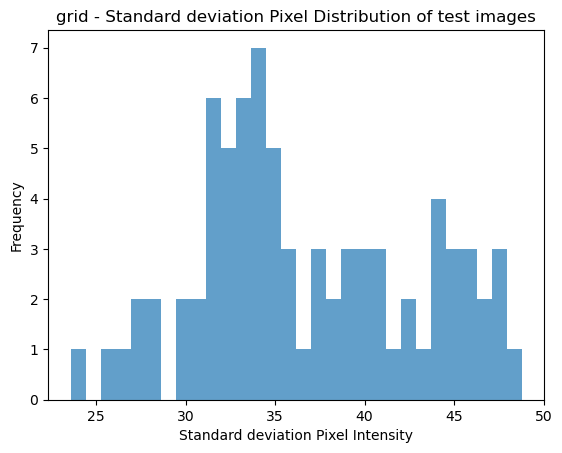

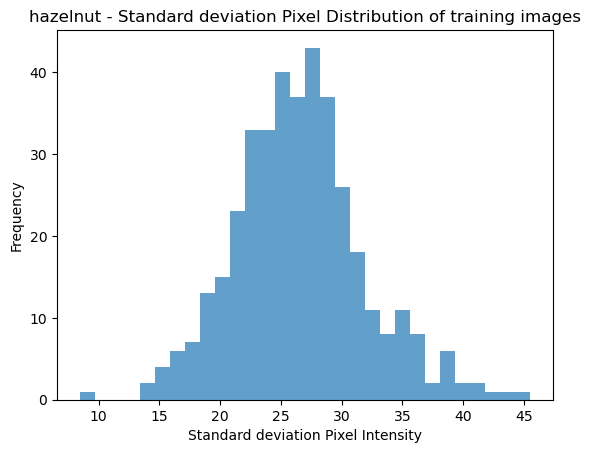

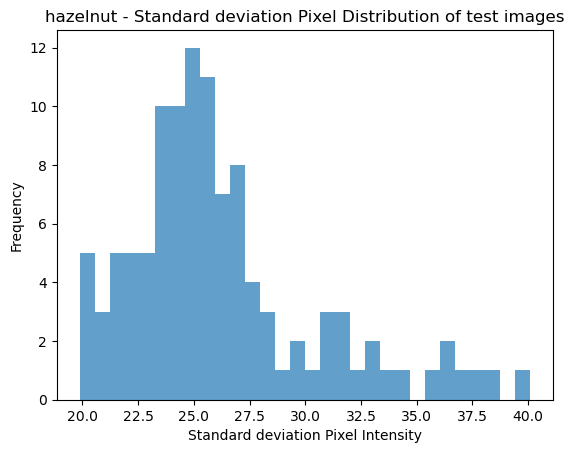

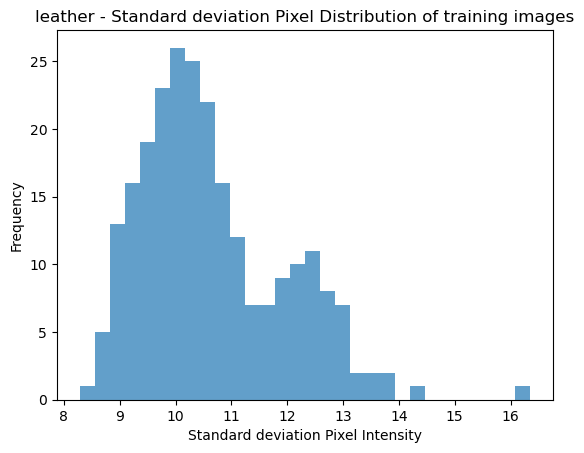

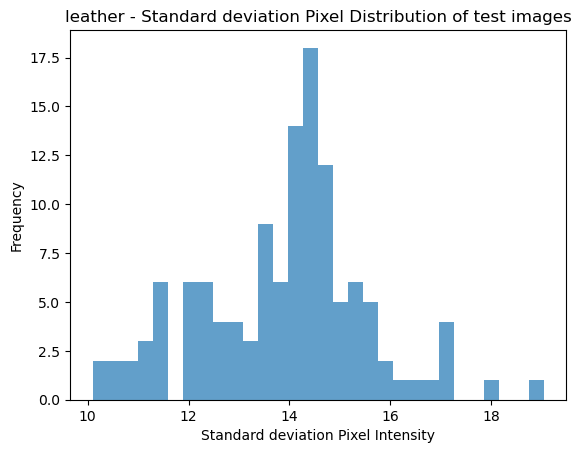

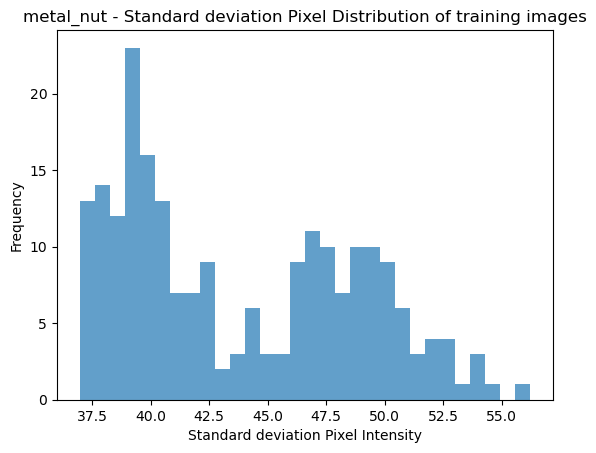

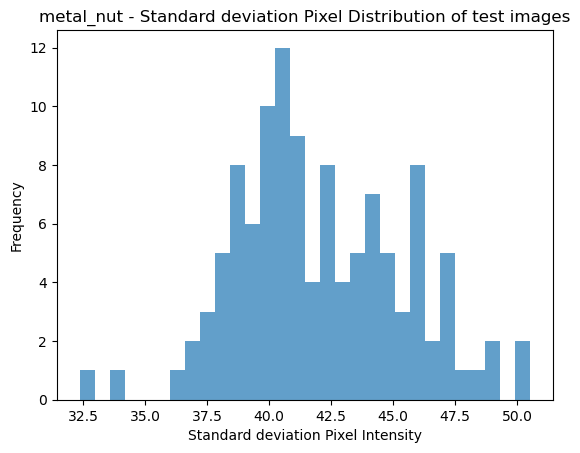

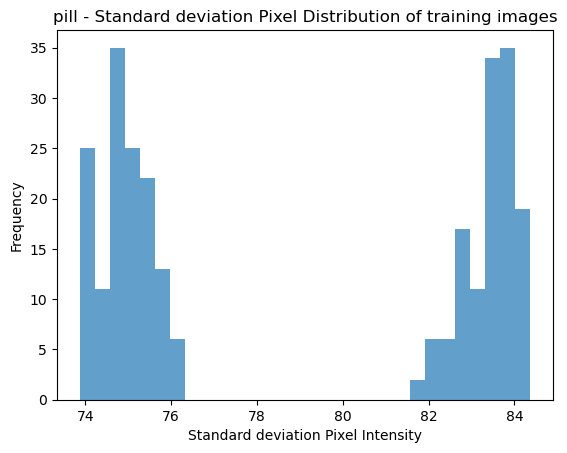

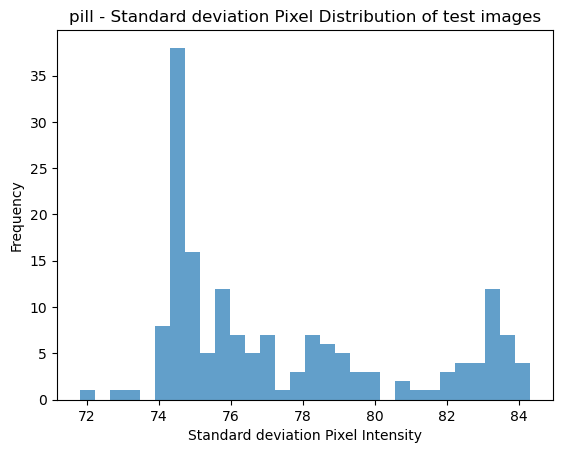

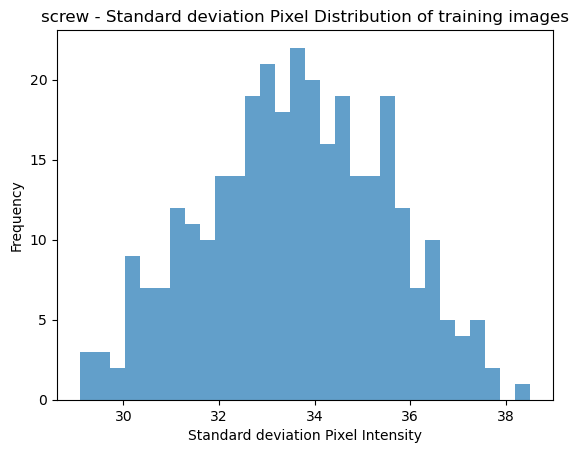

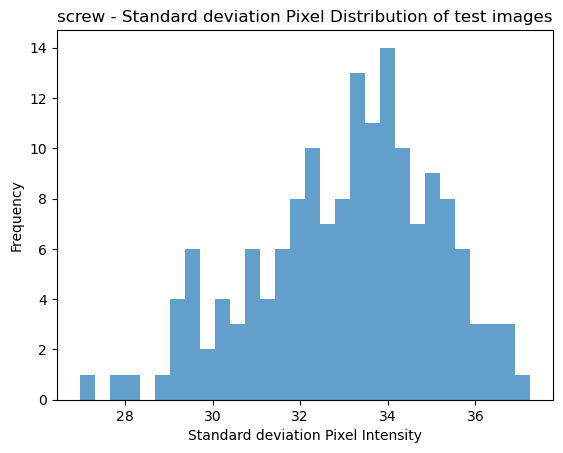

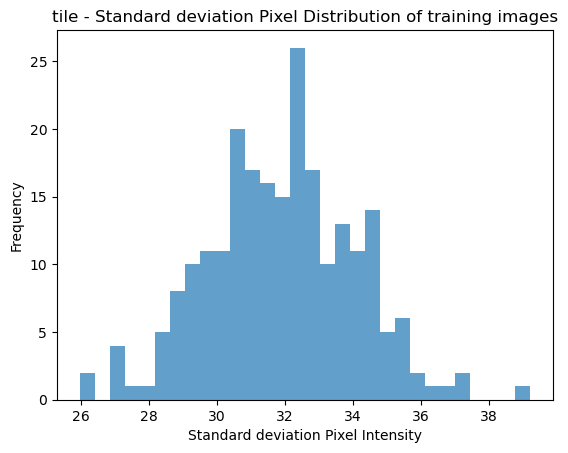

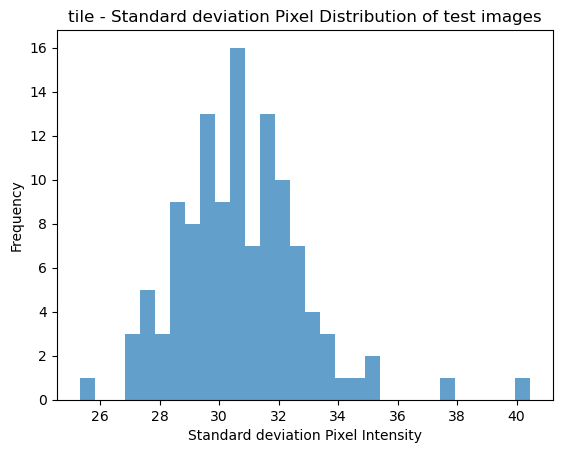

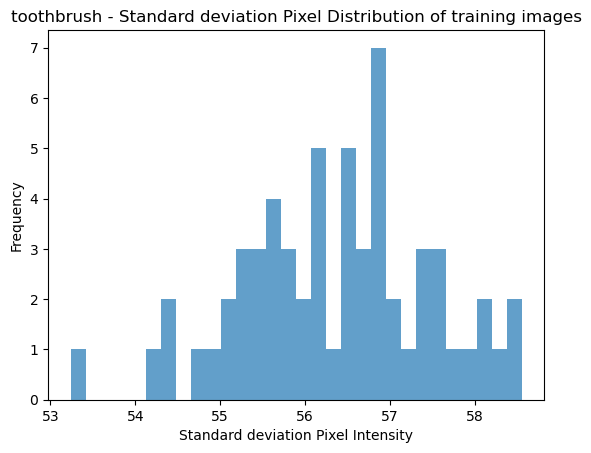

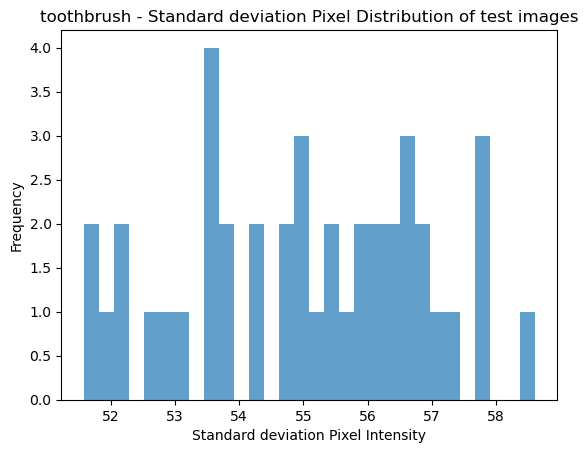

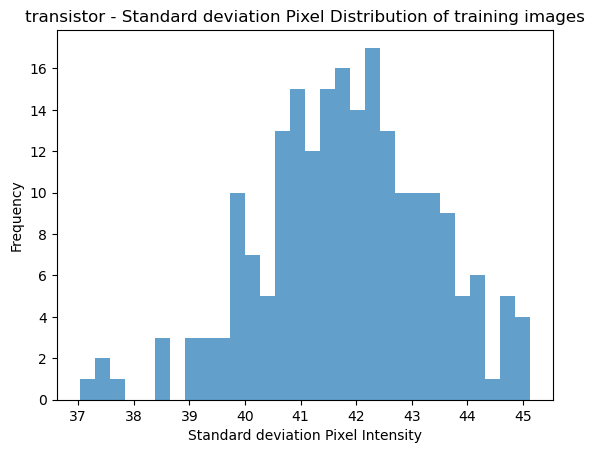

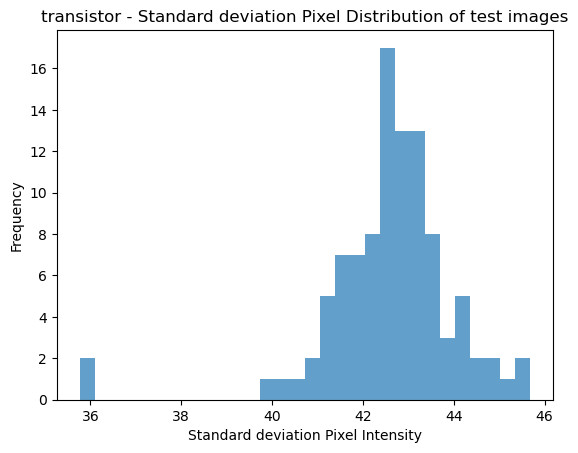

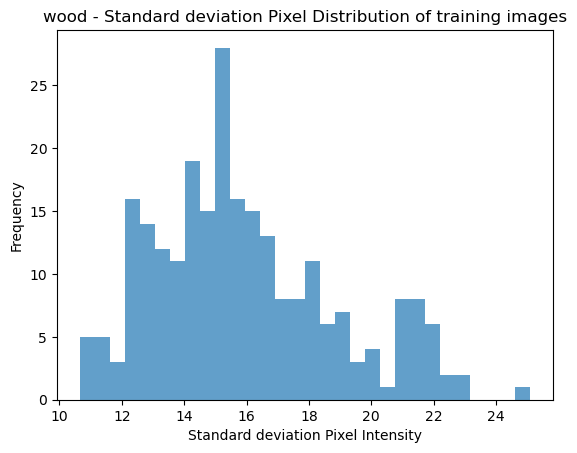

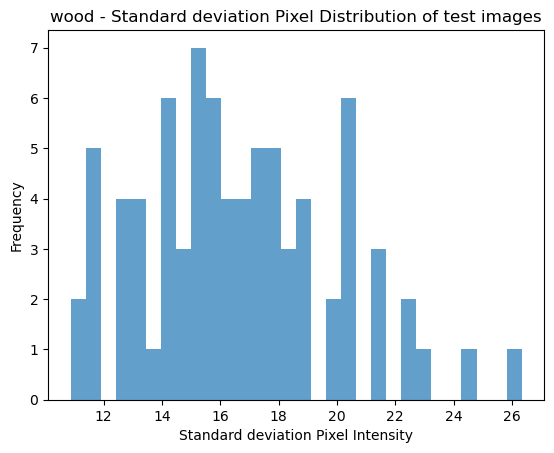

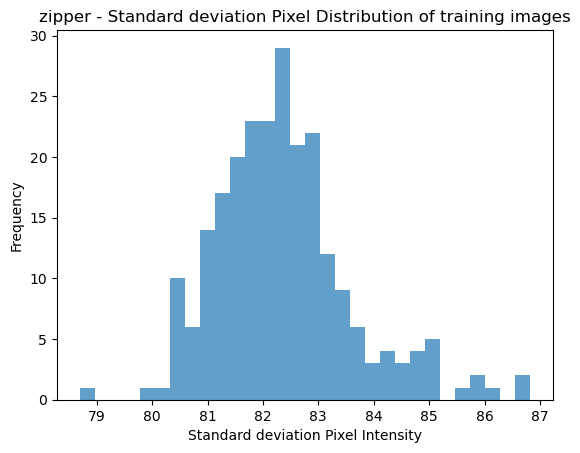

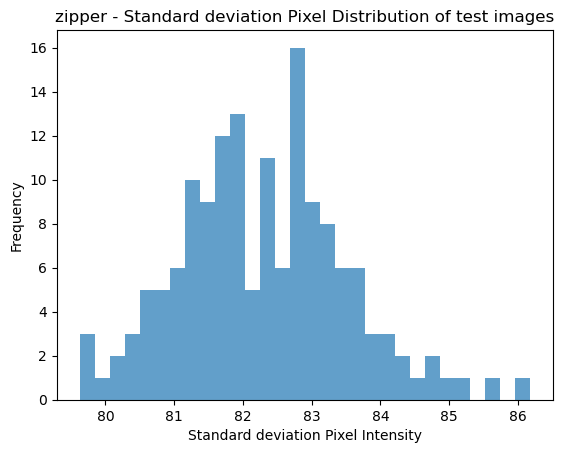

In [51]:
# Analysis graphs comparing colour contrast of test and train images in each category
categories = [p.name for p in Path(f"../Projects/mvtec_anomaly_detection/").iterdir() if p.is_dir()]
#categories = ["bottle","cable"]
gray_stds_all = []

for category in categories:
    gray_stds = []

    train_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/train")
    test_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/test")

    train_files = [f for f in train_dir.rglob('*') if f.is_file()]
    test_files = [f for f in test_dir.rglob('*') if f.is_file()]

    for img in train_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        gray_stds.append(np.std(img_array))
    gray_stds_all.append(np.mean(gray_stds))

    plt.hist(gray_stds, bins=30, alpha=0.7)
    plt.title(category + " - Standard deviation Pixel Distribution of training images")
    plt.xlabel("Standard deviation Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()


    gray_stds = []
    for img in test_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        gray_stds.append(np.std(img_array))
        
    plt.hist(gray_stds, bins=30, alpha=0.7)
    plt.title(category + " - Standard deviation Pixel Distribution of test images")
    plt.xlabel("Standard deviation Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()
  

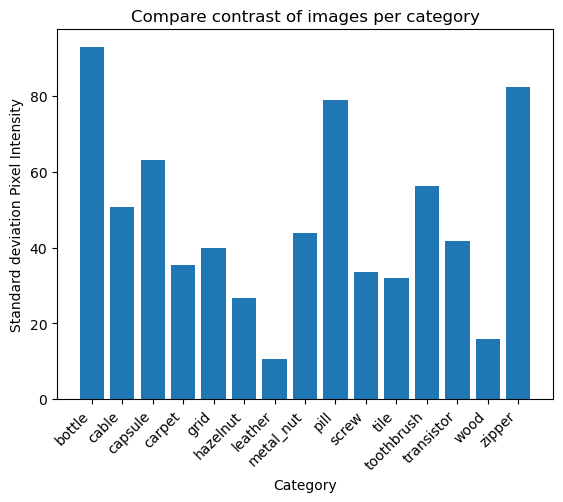

In [52]:
# Analysis graph to compare colour constrast of train images in all categories
plt.bar(categories, gray_stds_all)
plt.xticks(categories, categories, rotation=45, ha="right" );
plt.title("Compare contrast of images per category")
plt.xlabel("Category")
plt.ylabel("Standard deviation Pixel Intensity");

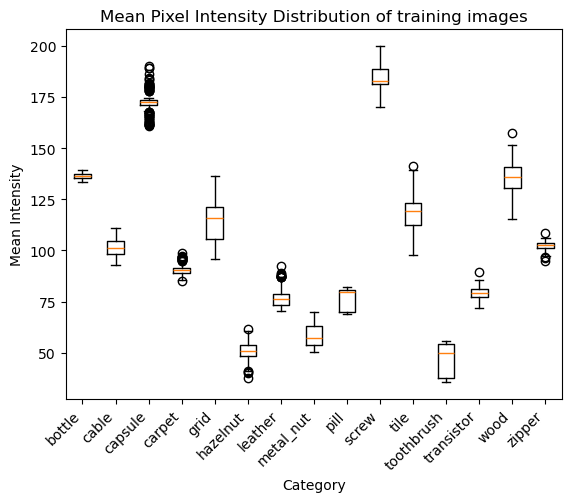

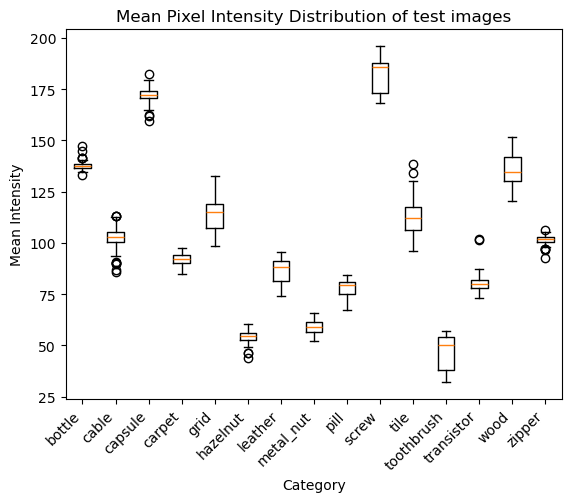

In [5]:
# Boxplot graphs comparing brightness of test and train images of each category
# Boxplot 1 - Brightness of train image of all categories
# Boxplot 2 - Brightness of train image of all categories

categories = [p.name for p in Path(f"../Projects/mvtec_anomaly_detection/").iterdir() if p.is_dir()]
#categories = ["bottle","cable","capsule"]
gray_means_train = []
gray_means_test = []		

for category in categories:
    means_train = []
    means_test = []

    train_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/train")
    test_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/test")

    train_files = [f for f in train_dir.rglob('*') if f.is_file()]
    test_files = [f for f in test_dir.rglob('*') if f.is_file()]

    for img in train_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        means_train.append(np.mean(img_array))

    for img in test_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        means_test.append(np.mean(img_array))
		
    gray_means_train.append(means_train)
    gray_means_test.append(means_test)
 
plt.boxplot(gray_means_train)
plt.title("Mean Pixel Intensity Distribution of training images")
plt.xlabel("Category")
plt.ylabel("Mean Intensity")
plt.xticks(range(1,16), categories, rotation=45, ha="right" );
plt.show()

plt.boxplot(gray_means_test)
plt.title("Mean Pixel Intensity Distribution of test images")
plt.xlabel("Category")
plt.ylabel("Mean Intensity")
plt.xticks(range(1,16), categories, rotation=45, ha="right" );
plt.show()


C:\Users\kavit\AppData\Local\Temp\ipykernel_28548\1242091361.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


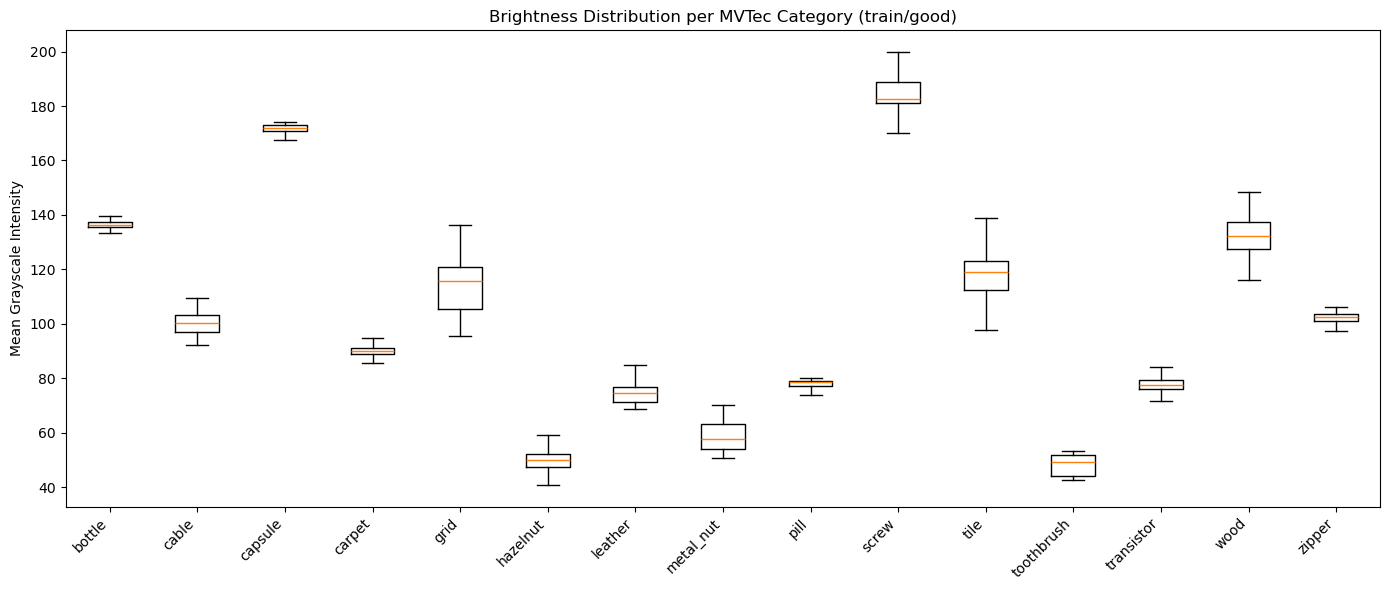

In [7]:
# Boxplot graph comparing brightness of all test and train images 

MVTEC_ROOT = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection"

def image_brightness(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.mean()

category_brightness = {}

for category in sorted(os.listdir(MVTEC_ROOT)):
    category_path = os.path.join(MVTEC_ROOT, category, "train", "good")
    if not os.path.isdir(category_path):
        continue

    brightness_values = []

    for img_name in (os.listdir(category_path)):
        img_path = os.path.join(category_path, img_name)
        val = image_brightness(img_path)
        if val is not None:
            brightness_values.append(val)

    category_brightness[category] = brightness_values

# ---- Boxplot ----
plt.figure(figsize=(14, 6))
plt.boxplot(
    category_brightness.values(),
    tick_labels=category_brightness.keys(),
    showfliers=False
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Grayscale Intensity")
plt.title("Brightness Distribution per Category (train/good)")
plt.tight_layout()
plt.show()

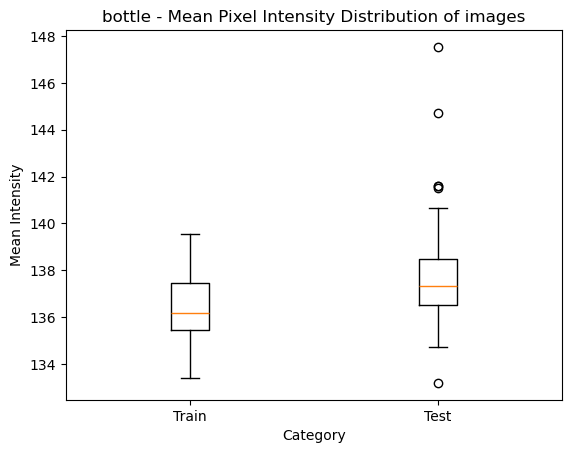

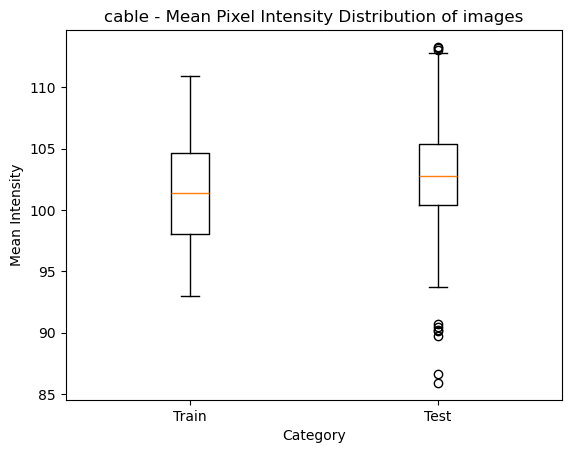

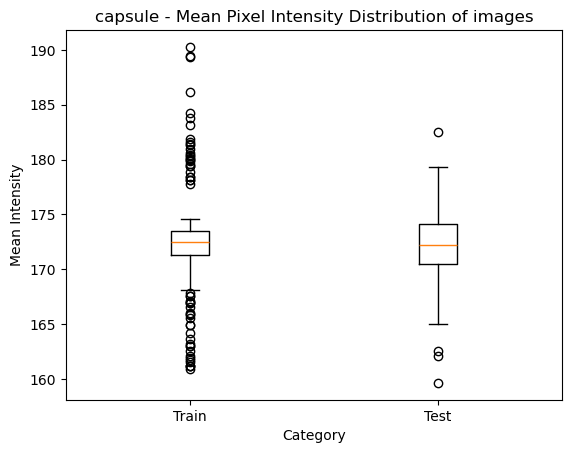

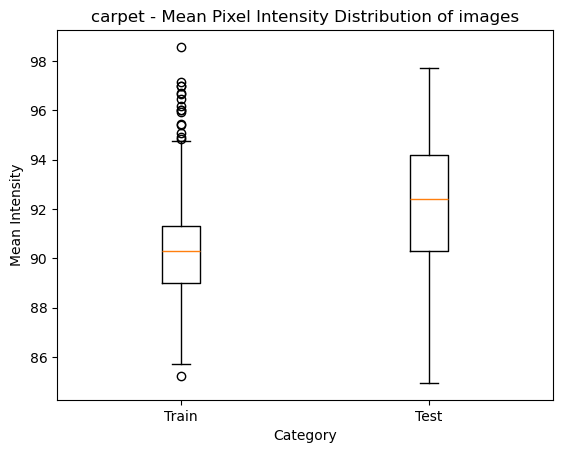

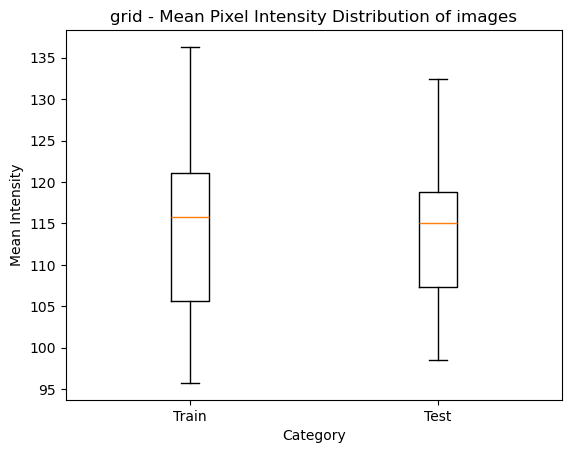

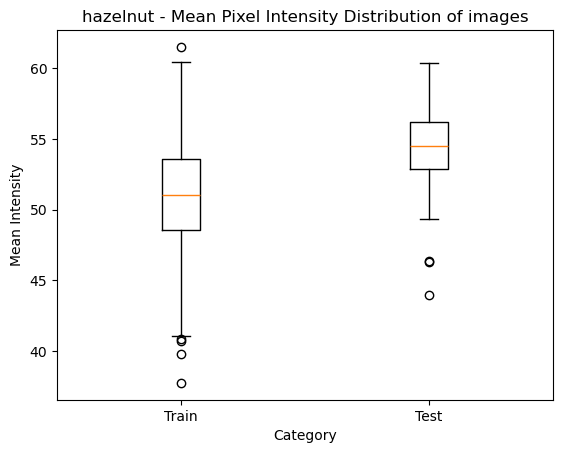

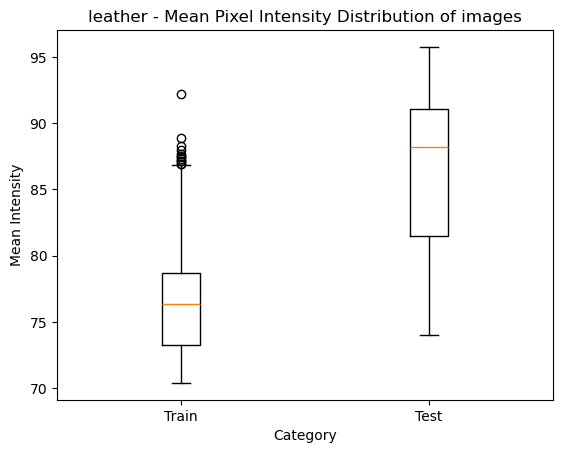

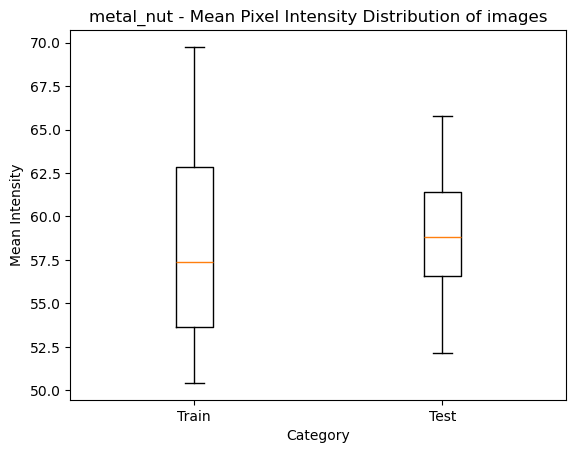

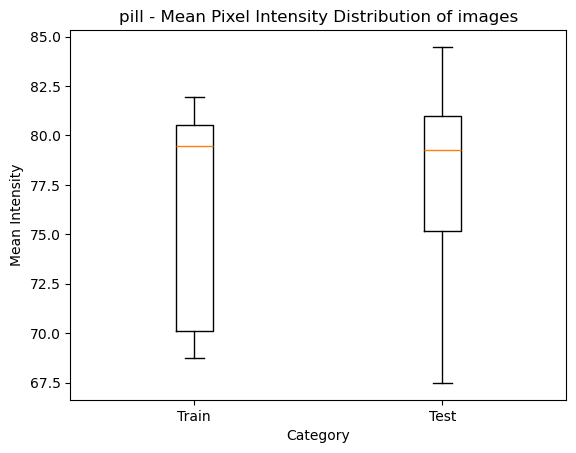

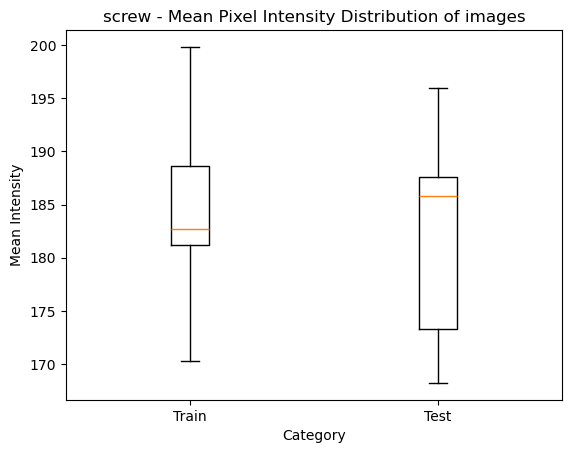

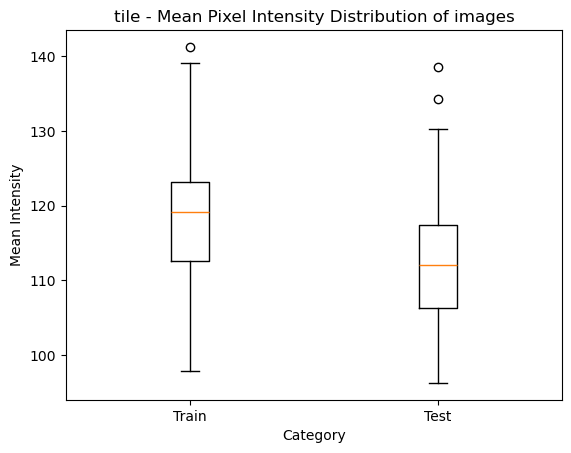

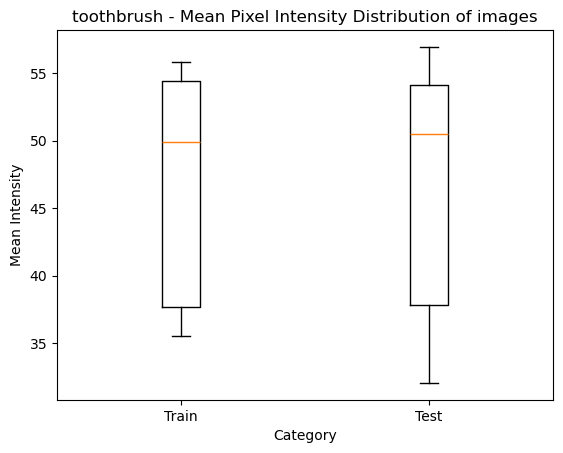

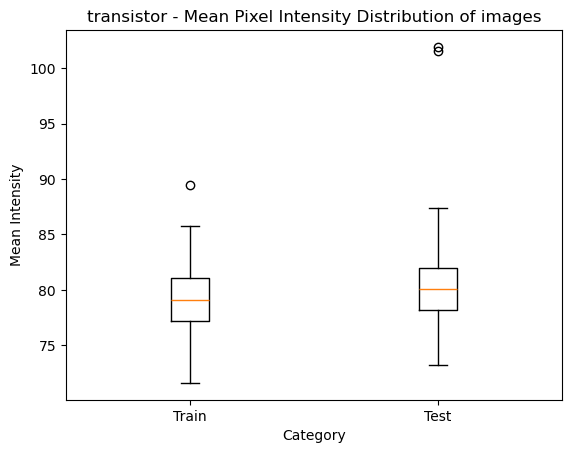

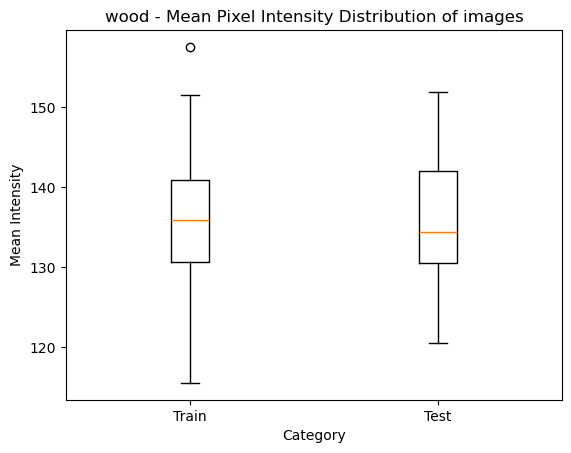

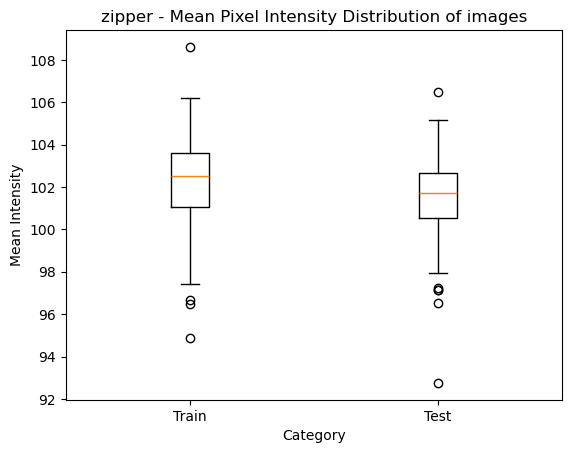

In [22]:
# Boxplot graphs comparing brightness of test and train images of each category

categories = [p.name for p in Path(f"../Projects/mvtec_anomaly_detection/").iterdir() if p.is_dir()]
#categories = ["bottle","cable","capsule"]	

for category in categories:
    means_train = []
    means_test = []
    gray_means = []

    train_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/train")
    test_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/test")

    train_files = [f for f in train_dir.rglob('*') if f.is_file()]
    test_files = [f for f in test_dir.rglob('*') if f.is_file()]

    for img in train_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        means_train.append(np.mean(img_array))

    for img in test_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        means_test.append(np.mean(img_array))
		
    gray_means.append(means_train)
    gray_means.append(means_test)
 
    plt.boxplot(gray_means, tick_labels=["Train","Test"])
    plt.title(category+ " - Mean Pixel Intensity Distribution of images")
    plt.xlabel("Category")
    plt.ylabel("Mean Intensity")
    #plt.xticks(range(1,), categories, rotation=45, ha="right" );
    plt.show()


C:\Users\kavit\AppData\Local\Temp\ipykernel_28548\3852623147.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


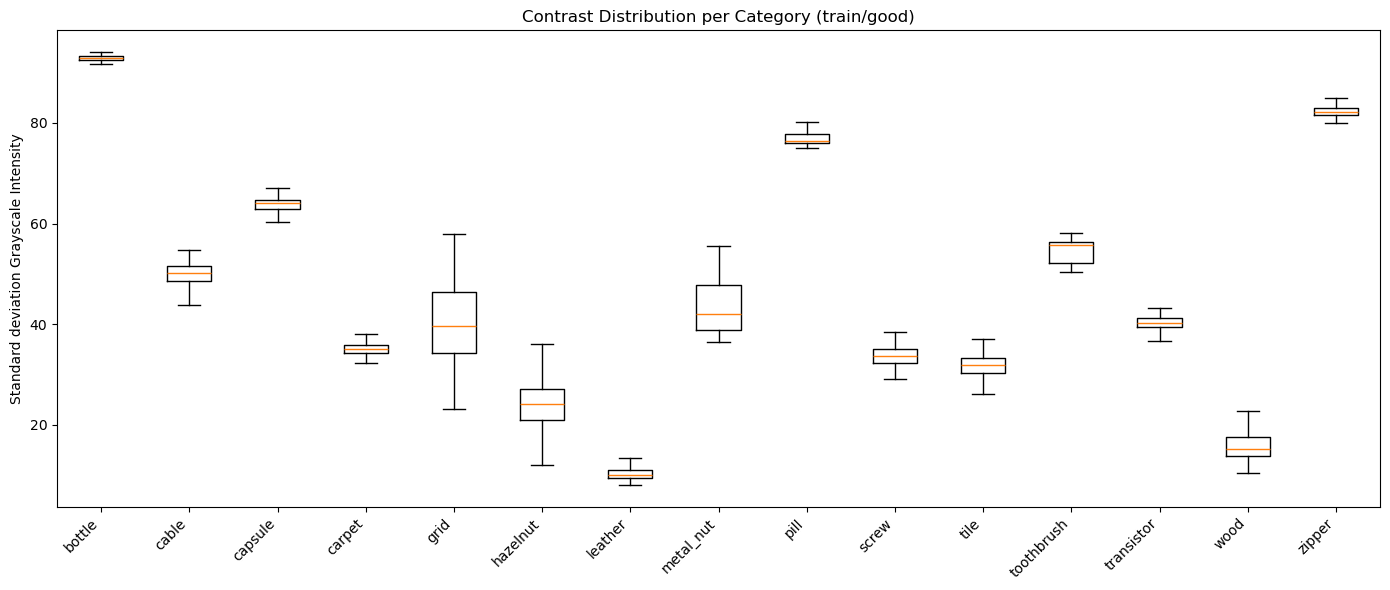

In [19]:
# Boxplot graph comparing contrast of all training images

MVTEC_ROOT = "C:/Kavitha/DataScientest/Projects/mvtec_anomaly_detection"

def image_contrast(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.std()

category_contrast = {}

for category in sorted(os.listdir(MVTEC_ROOT)):
    category_path = os.path.join(MVTEC_ROOT, category, "train", "good")
    if not os.path.isdir(category_path):
        continue

    contrast_values = []

    for img_name in (os.listdir(category_path)):
        img_path = os.path.join(category_path, img_name)
        val = image_contrast(img_path)
        if val is not None:
            contrast_values.append(val)

    category_contrast[category] = contrast_values

# ---- Boxplot ----
plt.figure(figsize=(14, 6))
plt.boxplot(
    category_contrast.values(),
    labels=category_contrast.keys(),
    showfliers=False
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Standard deviation Grayscale Intensity")
plt.title("Contrast Distribution per Category (train/good)")
plt.tight_layout()
plt.show()

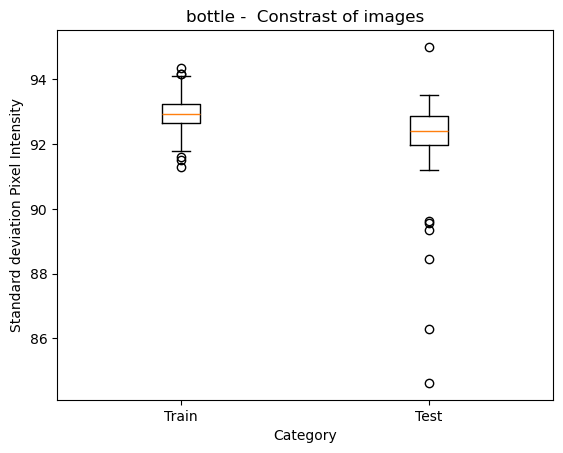

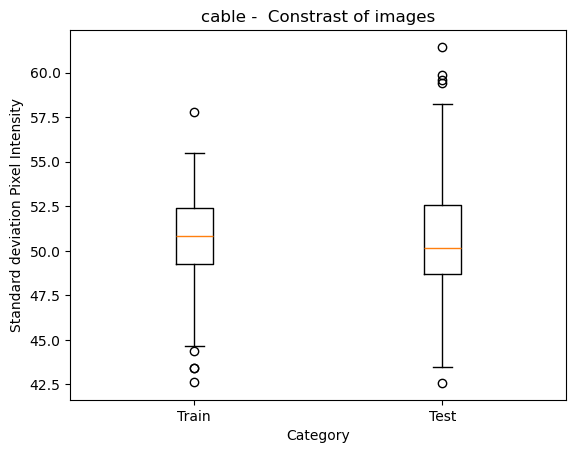

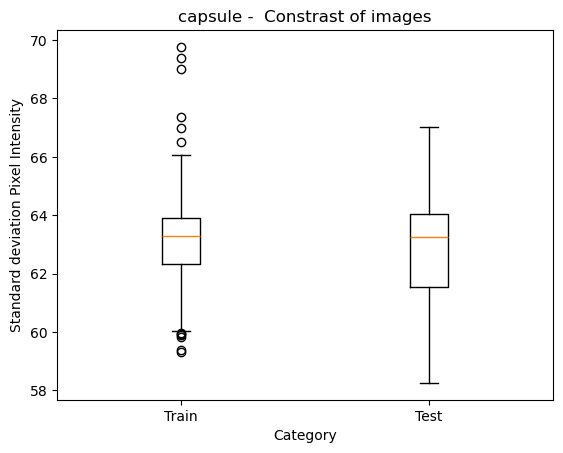

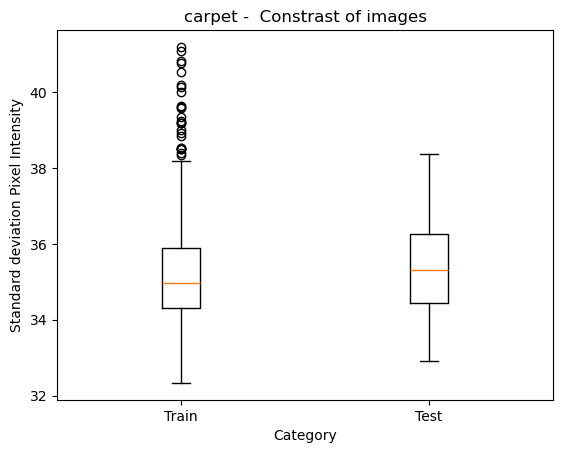

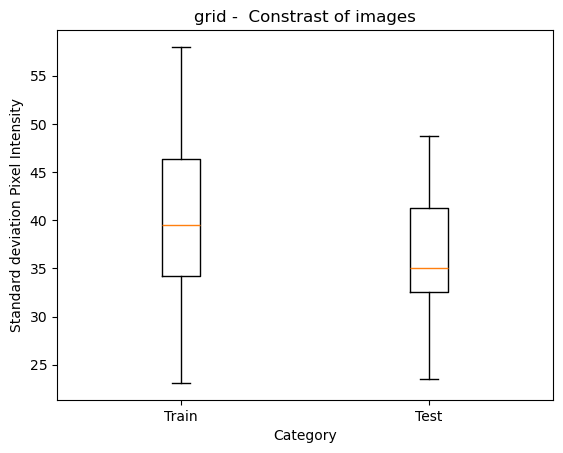

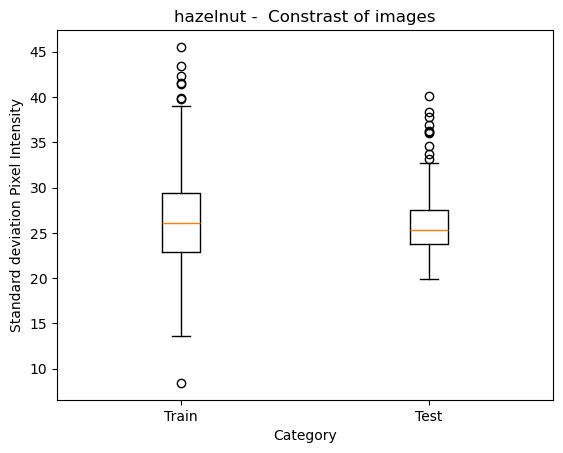

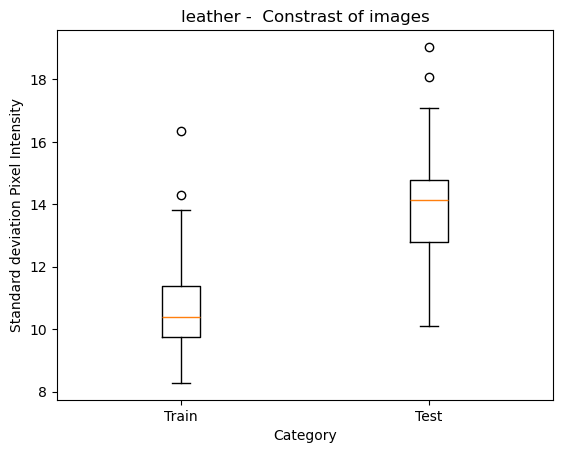

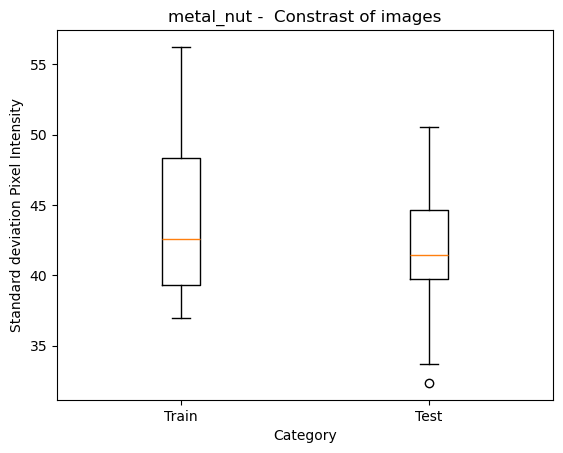

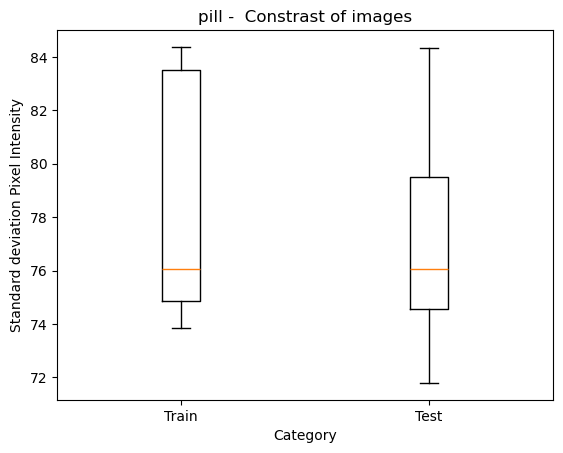

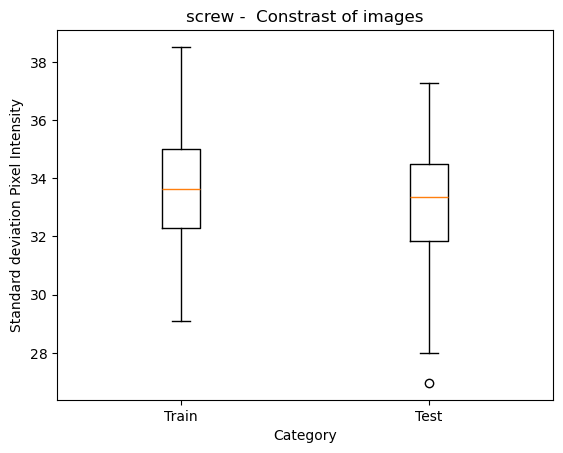

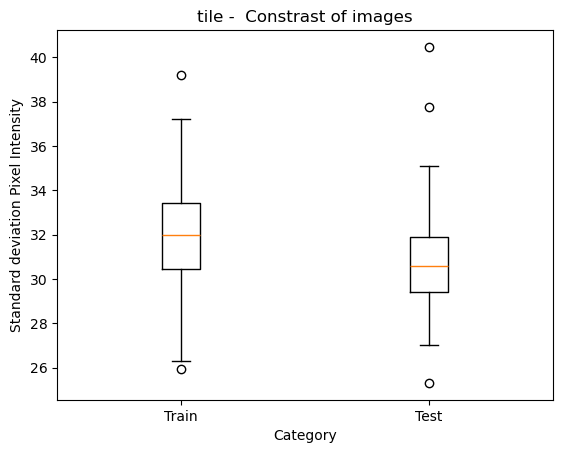

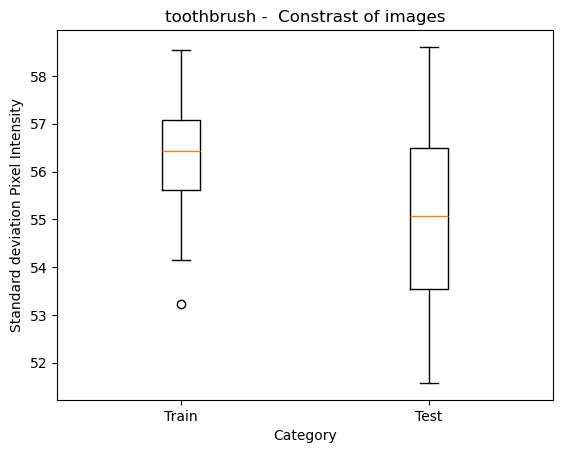

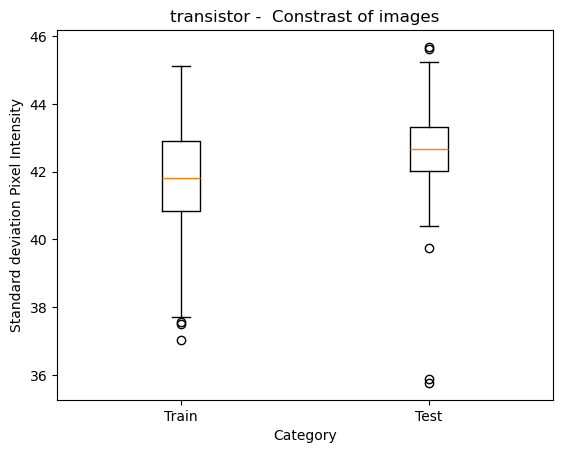

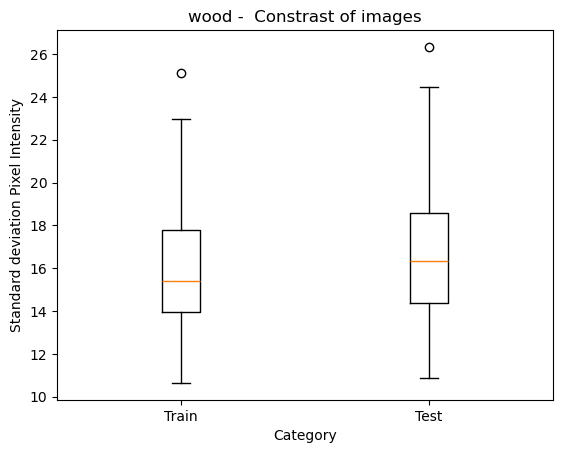

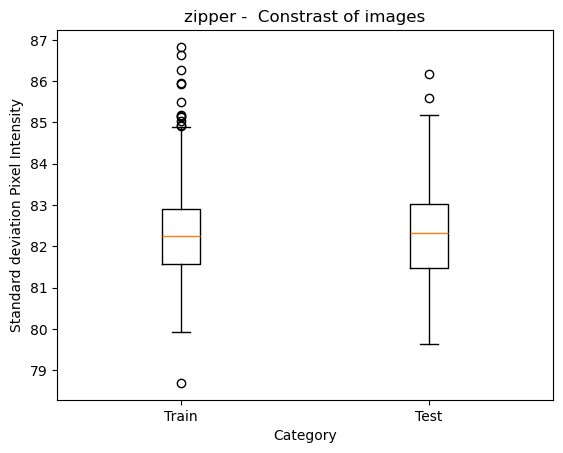

In [21]:
# Boxplot graphs comparing constrast of test and train images of each category

categories = [p.name for p in Path(f"../Projects/mvtec_anomaly_detection/").iterdir() if p.is_dir()]
#categories = ["bottle","cable","capsule"]	

for category in categories:
    std_train = []
    std_test = []
    gray_stds = []

    train_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/train")
    test_dir = Path(f"../Projects/mvtec_anomaly_detection/{category}/test")

    train_files = [f for f in train_dir.rglob('*') if f.is_file()]
    test_files = [f for f in test_dir.rglob('*') if f.is_file()]

    for img in train_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        std_train.append(np.std(img_array))

    for img in test_files:
        img = cv2.imread(img,cv2.IMREAD_GRAYSCALE)
        img_array = np.array(img)
        std_test.append(np.std(img_array))
		
    gray_stds.append(std_train)
    gray_stds.append(std_test)
 
    plt.boxplot(gray_stds, tick_labels=["Train","Test"])
    plt.title(category+ " -  Constrast of images")
    plt.xlabel("Category")
    plt.ylabel("Standard deviation Pixel Intensity")
    plt.show()
